In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('../02_Data/processed/final_rewards_features_merged.csv')
comments_df = pd.read_csv('../02_Data/processed/comments_merged.csv')


c:\Users\seon\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\seon\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


FileNotFoundError: [Errno 2] No such file or directory: '../02_Data/processed/final_rewards_features_merged.csv'

## 2. 태그(Tags) 데이터 전처리 및 분석
문자열 형태의 태그를 리스트로 변환하고, 개별 태그별 성과를 분석합니다.

In [ ]:
def parse_tags(tag_str):
    try:
        return ast.literal_eval(tag_str)
    except:
        return [t.strip() for t in str(tag_str).split(',')]

df_tags = df.copy()
df_tags['tag_list'] = df_tags['projectTags'].apply(parse_tags)
df_exploded = df_tags.explode('tag_list')

unique_tags = df_exploded['tag_list'].nunique()
print(f"총 고유 태그 개수: {unique_tags}개")

# 태그별 평균 모금액 상위 10개 출력
tag_summary = df_exploded.groupby('tag_list').agg(
    avg_funds=('fundsGathered_usd_1m', 'mean'),
    count=('projectID', 'count')
).query('count >= 5').sort_values('avg_funds', ascending=False)

display(tag_summary.head(10))

총 고유 태그 개수: 63개


,avg_funds,count
tag_list,,
Video Game Theme,1.443026e+06,17
Narrative,9.932934e+05,45
RPG,9.275699e+05,49
Exploration,8.726726e+05,88
Economic,7.852451e+05,41
Adventure,7.273332e+05,129
Collectible Models,7.057485e+05,23
Cooperative,6.855386e+05,121
Fantasy,5.434956e+05,161


## 3. 최종 모금액 및 주요 지표 분석
목표 금액, 후원자 수, 모금 속도 등 핵심 지표와 최종 모금액 간의 관계를 확인합니다.

목표 금액과 모금액 상관계수: 0.4219
후원자 수와 모금액 상관계수: 0.9607


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

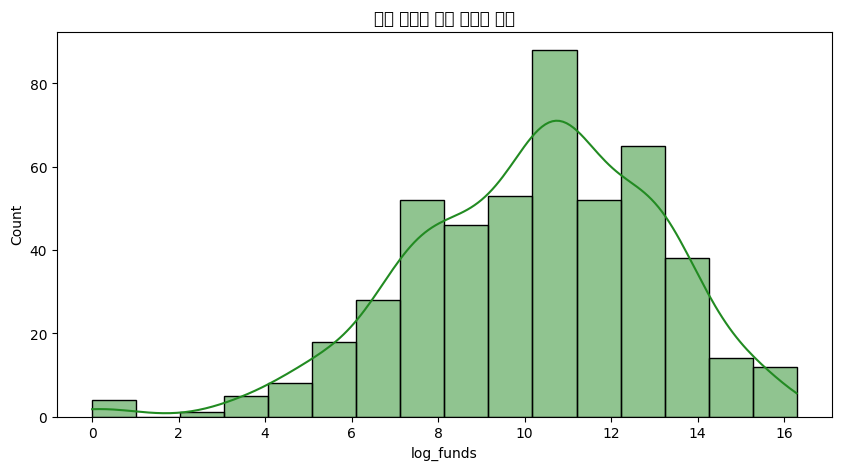

In [ ]:
# 1. 목표 금액 vs 실제 모금액 상관관계
corr_goal = df['campaignGoal_usd_6m'].corr(df['fundsGathered_usd_1m'])
print(f"목표 금액과 모금액 상관계수: {corr_goal:.4f}")

# 2. 후원자 수 vs 실제 모금액 상관관계
corr_backers = df['backersCount'].corr(df['fundsGathered_usd_1m'])
print(f"후원자 수와 모금액 상관계수: {corr_backers:.4f}")

# 3. 모금액 분포 확인 (로그 변환)
df['log_funds'] = np.log1p(df['fundsGathered_usd_1m'])

plt.figure(figsize=(10, 5))
sns.histplot(df['log_funds'], kde=True, color='forestgreen')
plt.title('로그 변환된 최종 모금액 분포')
plt.show()

In [4]:
!sudo apt-get install -qq -y fonts-nanum

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 설정 적용
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [5]:
import pandas as pd

# Load the uploaded dataset
file_path = '/content/drive/MyDrive/0_ASAC_11기_ML_4조/02_Data/processed/final_rewards_features_merged.csv'
df = pd.read_csv(file_path)

# Display basic information and the first 5 rows
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   projectID                  484 non-null    int64  
 1   currencySymbol             484 non-null    object 
 2   backersCount               484 non-null    int64  
 3   phaseLabel                 484 non-null    object 
 4   enableBoardGameProperties  484 non-null    bool   
 5   minPlayers                 470 non-null    float64
 6   maxPlayers                 470 non-null    float64
 7   minAge                     453 non-null    float64
 8   playTime                   457 non-null    float64
 9   fundedInSeconds            484 non-null    int64  
 10  projectTags                484 non-null    object 
 11  isDiscounted               484 non-null    bool   
 12  isFeatured                 484 non-null    bool   
 13  installmentMinPayment      253 non-null    float64

,projectID,currencySymbol,backersCount,phaseLabel,enableBoardGameProperties,minPlayers,maxPlayers,minAge,playTime,fundedInSeconds,...,sum_pledge_master,avg_pledge_master,sum_backer,avg_backer,sum_prior_backer,avg_prior_backer,sum_pathfinder,avg_pathfinder,sum_no_badge,avg_no_badge_ratio
0,5787,$,1567,Pledge manager - Closed,False,NaN,NaN,NaN,NaN,628,...,70.0,0.204082,139.0,0.405248,55.0,0.160350,0.0,0.0,174.0,0.507289
1,6481,$,1075,Pledge manager - Closed,True,1.0,4.0,13.0,90.0,2716,...,61.0,0.174286,105.0,0.300000,11.0,0.031429,0.0,0.0,206.0,0.588571
2,8024,$,215,Pledge manager - Closed,True,1.0,2.0,12.0,480.0,56442,...,5.0,0.250000,9.0,0.450000,2.0,0.100000,0.0,0.0,11.0,0.550000
3,8225,$,12,Pledge manager - Closed,True,2.0,5.0,8.0,15.0,2409627,...,0.0,0.000000,2.0,0.500000,0.0,0.000000,0.0,0.0,2.0,0.500000
4,5995,€,89,Pledge manager - Closed,True,2.0,6.0,8.0,20.0,14439,...,10.0,0.322581,13.0,0.419355,0.0,0.000000,0.0,0.0,17.0,0.548387


In [6]:
import pandas as pd

# comments_merged.csv 파일 로드
comments_file_path = '/content/drive/MyDrive/0_ASAC_11기_ML_4조/02_Data/processed/comments_merged.csv'
comments_df = pd.read_csv(comments_file_path)

# 기본 정보 및 상위 5개 행 출력
print("Comments Dataset Info:")
print(comments_df.info())
display(comments_df.head())

Comments Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212988 entries, 0 to 212987
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   projectID         212988 non-null  int64  
 1   comment_id        212988 non-null  int64  
 2   parent_id         139549 non-null  float64
 3   depth_level       212988 non-null  int64  
 4   author_id         212988 non-null  int64  
 5   author_name       212987 non-null  object 
 6   creator_id        212988 non-null  int64  
 7   is_pledge_master  212988 non-null  bool   
 8   is_backer         212988 non-null  bool   
 9   backer_number     111472 non-null  float64
 10  is_prior_backer   212988 non-null  bool   
 11  is_pathfinder     212988 non-null  bool   
 12  has_children      212988 non-null  bool   
 13  children_count    212988 non-null  int64  
 14  text              212979 non-null  object 
 15  created_at        212988 non-null  object 
 1

,projectID,comment_id,parent_id,depth_level,author_id,...,likes,phaseLabel,campaignStart,campaignEnd,group
0,5787,1691589,NaN,0,1456332,...,26,Pledge manager - Closed,2025-06-17 14:30:00+00:00,2025-07-19 00:50:35.250000+00:00,0
1,5787,1725920,NaN,0,9482,...,0,Pledge manager - Closed,2025-06-17 14:30:00+00:00,2025-07-19 00:50:35.250000+00:00,0
2,5787,1726005,1725920.0,1,1456332,...,0,Pledge manager - Closed,2025-06-17 14:30:00+00:00,2025-07-19 00:50:35.250000+00:00,0
3,5787,1725876,NaN,0,137438,...,1,Pledge manager - Closed,2025-06-17 14:30:00+00:00,2025-07-19 00:50:35.250000+00:00,0
4,5787,1725671,NaN,0,12163,...,3,Pledge manager - Closed,2025-06-17 14:30:00+00:00,2025-07-19 00:50:35.250000+00:00,0


/tmp/ipykernel_560/402887843.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='currencySymbol', y='fundsGathered_usd_6m', data=df, estimator='mean', ci=None)


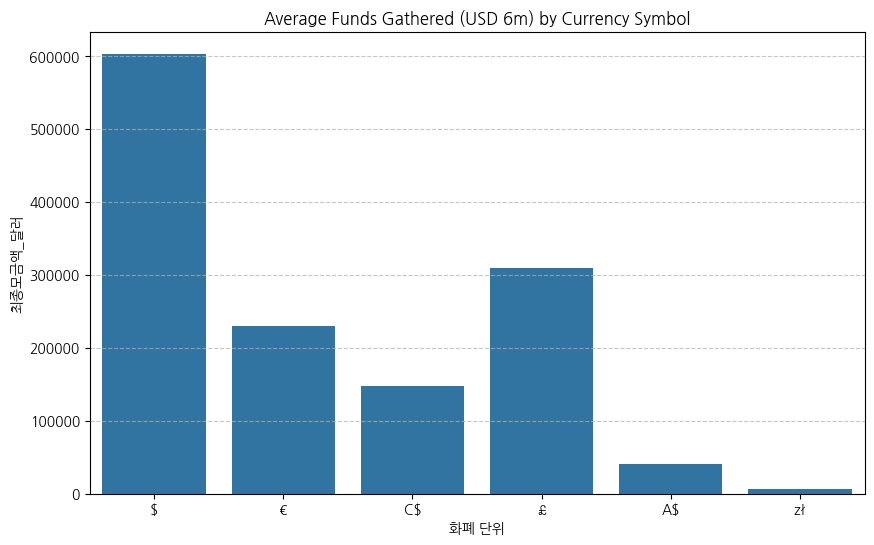

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size
plt.figure(figsize=(10, 6))

# Create a bar plot showing the average funds gathered by currency symbol
# Using 'fundsGathered_usd_1m' as the target variable for '최종모금액'
sns.barplot(x='currencySymbol', y='fundsGathered_usd_1m', data=df, estimator='mean', ci=None)

plt.title('Average Funds Gathered (USD 6m) by Currency Symbol')
plt.xlabel('화폐 단위')
plt.ylabel('최종모금액_달러')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

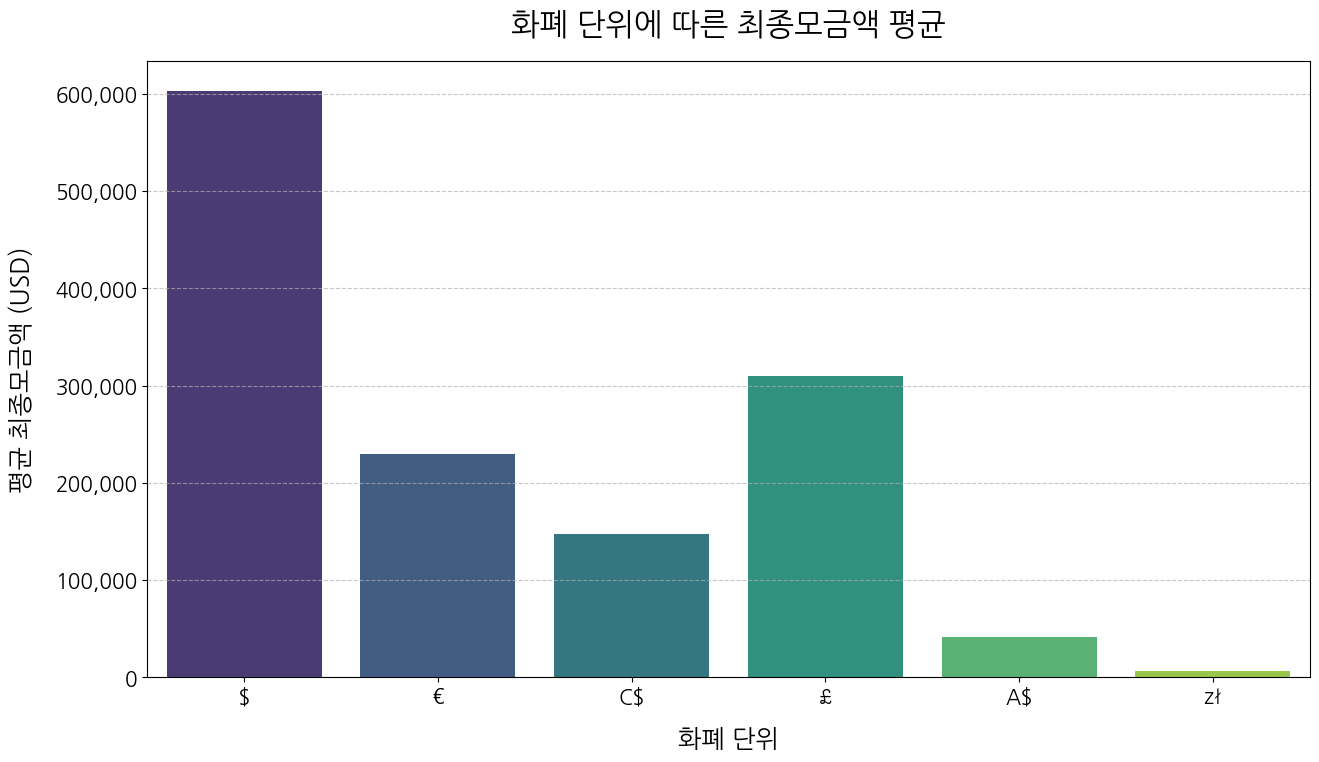

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 폰트 설정 및 크기 키워 다시 그래프 그리기
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='currencySymbol', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None, palette='viridis', hue='currencySymbol', legend=False)

# y축 천 단위 콤마 설정
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 폰트 크기 조정
plt.title('화폐 단위에 따른 최종모금액 평균', fontsize=22, pad=20)
plt.xlabel('화폐 단위', fontsize=18, labelpad=15)
plt.ylabel('평균 최종모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

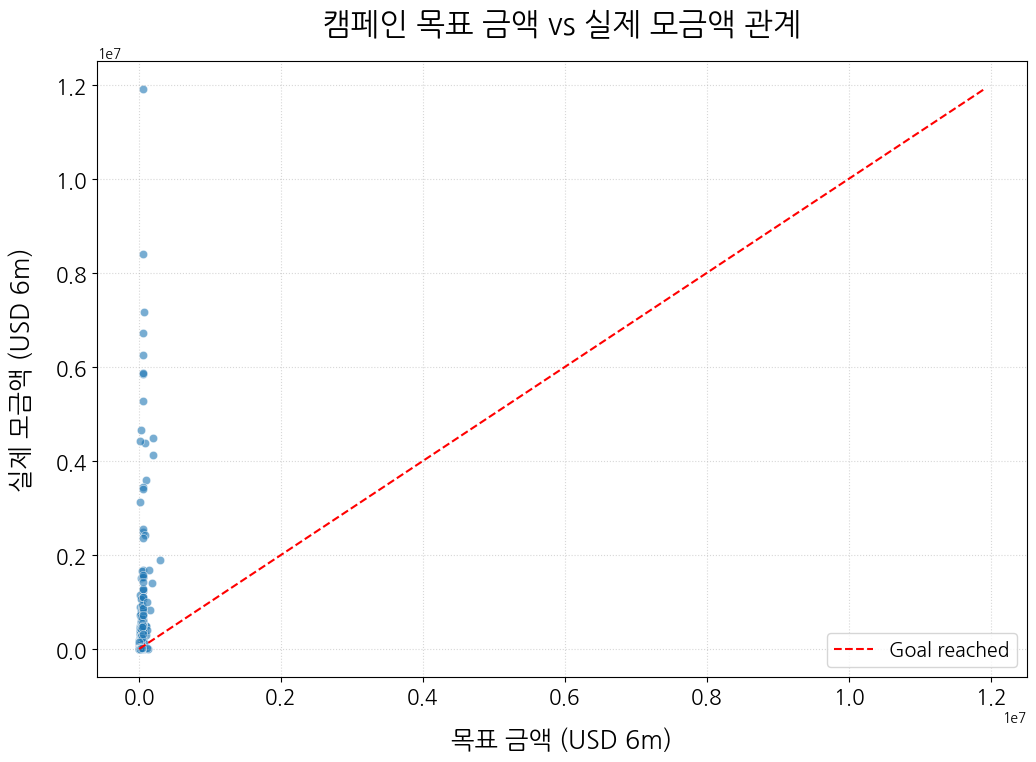

두 변수 간의 상관계수: 0.4219


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.scatterplot(x='campaignGoal_usd_6m', y='fundsGathered_usd_1m', data=df, alpha=0.6)

max_val = max(df['campaignGoal_usd_6m'].max(), df['fundsGathered_usd_1m'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Goal reached')

plt.title('캠페인 목표 금액 vs 실제 모금액 관계', fontsize=22, pad=20)
plt.xlabel('목표 금액 (USD 6m)', fontsize=18, labelpad=15)
plt.ylabel('실제 모금액 (USD 6m)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

correlation = df['campaignGoal_usd_6m'].corr(df['fundsGathered_usd_1m'])
print(f"두 변수 간의 상관계수: {correlation:.4f}")

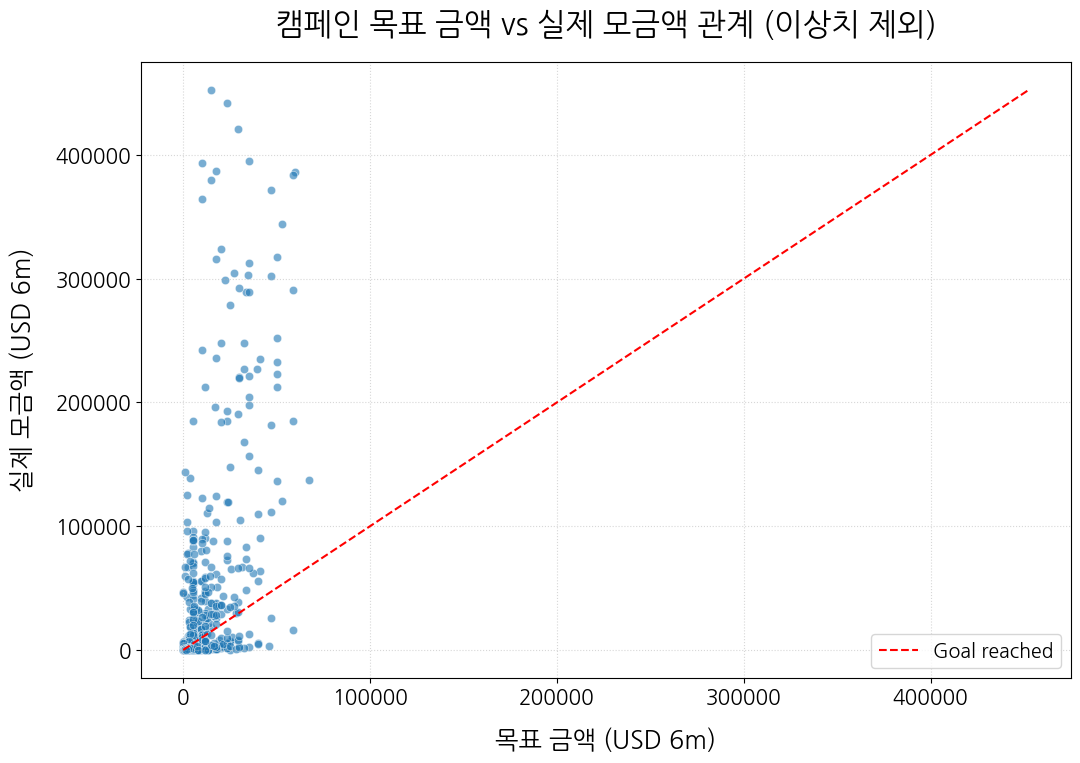

이상치 제거 후 상관계수: 0.5320


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이상치 제거 함수 정의 (정의되지 않았을 경우를 대비)
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# 2. 필터링 수행
df_filtered = remove_outliers(df, 'campaignGoal_usd_6m')
df_filtered = remove_outliers(df_filtered, 'fundsGathered_usd_1m')

# 3. 시각화
plt.figure(figsize=(12, 8))
sns.scatterplot(x='campaignGoal_usd_6m', y='fundsGathered_usd_1m', data=df_filtered, alpha=0.6)

max_val_filtered = max(df_filtered['campaignGoal_usd_6m'].max(), df_filtered['fundsGathered_usd_1m'].max())
plt.plot([0, max_val_filtered], [0, max_val_filtered], color='red', linestyle='--', label='Goal reached')

plt.title('캠페인 목표 금액 vs 실제 모금액 관계 (이상치 제외)', fontsize=22, pad=20)
plt.xlabel('목표 금액 (USD 6m)', fontsize=18, labelpad=15)
plt.ylabel('실제 모금액 (USD 6m)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

new_correlation = df_filtered['campaignGoal_usd_6m'].corr(df_filtered['fundsGathered_usd_1m'])
print(f"이상치 제거 후 상관계수: {new_correlation:.4f}")

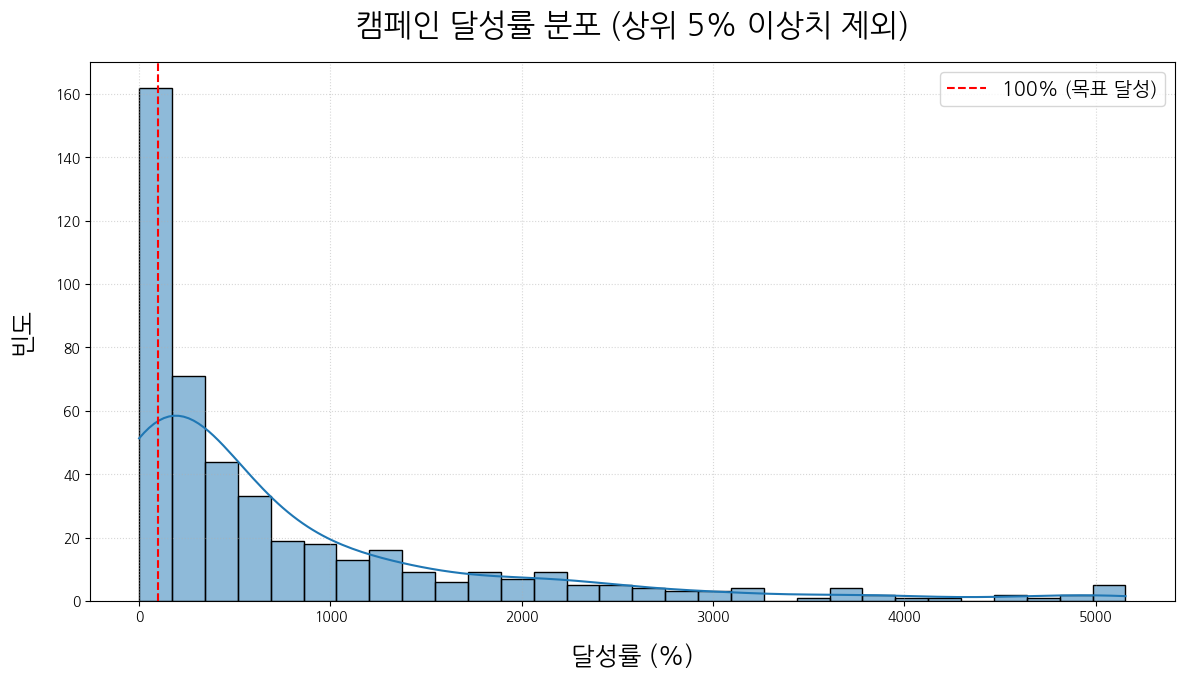

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 이상치 제거 함수 정의
def remove_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# 2. achievement_rate (달성률) 컬럼 생성
# 달성률 = (실제 모금액 / 목표 금액) * 100
df['achievement_rate'] = (df['fundsGathered_usd_1m'] / df['campaignGoal_usd_6m']) * 100

# 3. 달성률 분포 시각화 (상위 5% 이상치 제외)
plt.figure(figsize=(14, 7))
sns.histplot(df[df['achievement_rate'] <= df['achievement_rate'].quantile(0.95)]['achievement_rate'], bins=30, kde=True)

plt.title('캠페인 달성률 분포 (상위 5% 이상치 제외)', fontsize=22, pad=20)
plt.xlabel('달성률 (%)', fontsize=18, labelpad=15)
plt.ylabel('빈도', fontsize=18, labelpad=15)
plt.axvline(100, color='red', linestyle='--', label='100% (목표 달성)')
plt.legend(fontsize=14)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

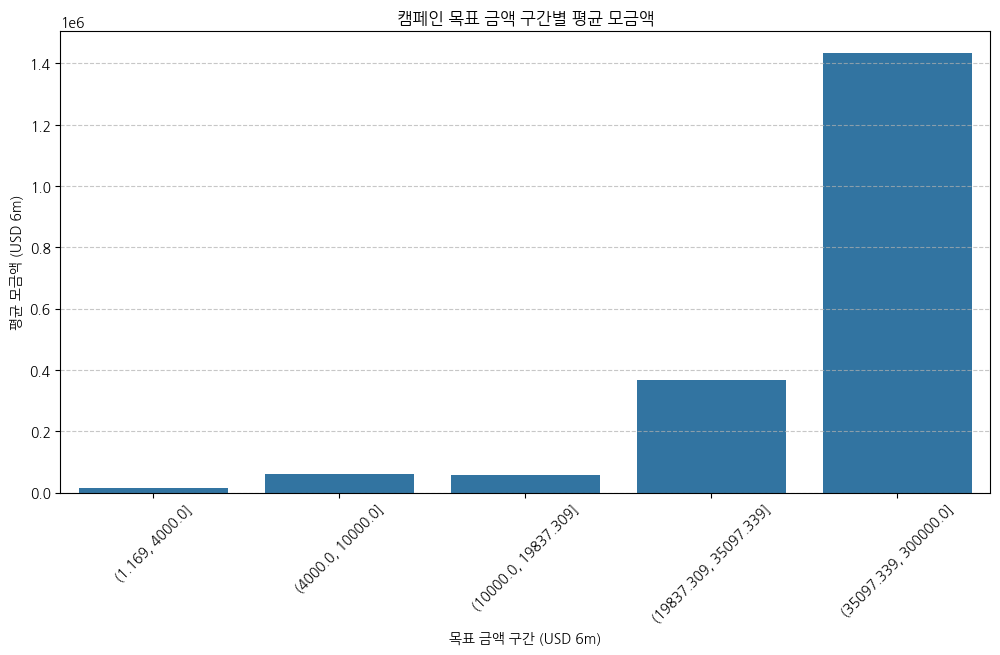

구간별 평균 모금액 상세:


,goal_range,fundsGathered_usd_6m
0,"(1.169, 4000.0]",1.604697e+04
1,"(4000.0, 10000.0]",5.910931e+04
2,"(10000.0, 19837.309]",5.734865e+04
3,"(19837.309, 35097.339]",3.668932e+05
4,"(35097.339, 300000.0]",1.435484e+06


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 목표 금액을 5개 구간으로 나누기 (qcut을 사용하여 데이터 개수가 균등하게 분할)
df['goal_range'] = pd.qcut(df['campaignGoal_usd_6m'], q=5)

# 구간별 평균 모금액 계산 및 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='goal_range', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None)

plt.title('캠페인 목표 금액 구간별 평균 모금액')
plt.xlabel('목표 금액 구간 (USD 6m)')
plt.ylabel('평균 모금액 (USD 6m)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 구간별 상세 수치 출력
goal_summary = df.groupby('goal_range', observed=True)['fundsGathered_usd_1m'].mean().reset_index()
print("구간별 평균 모금액 상세:")
display(goal_summary)

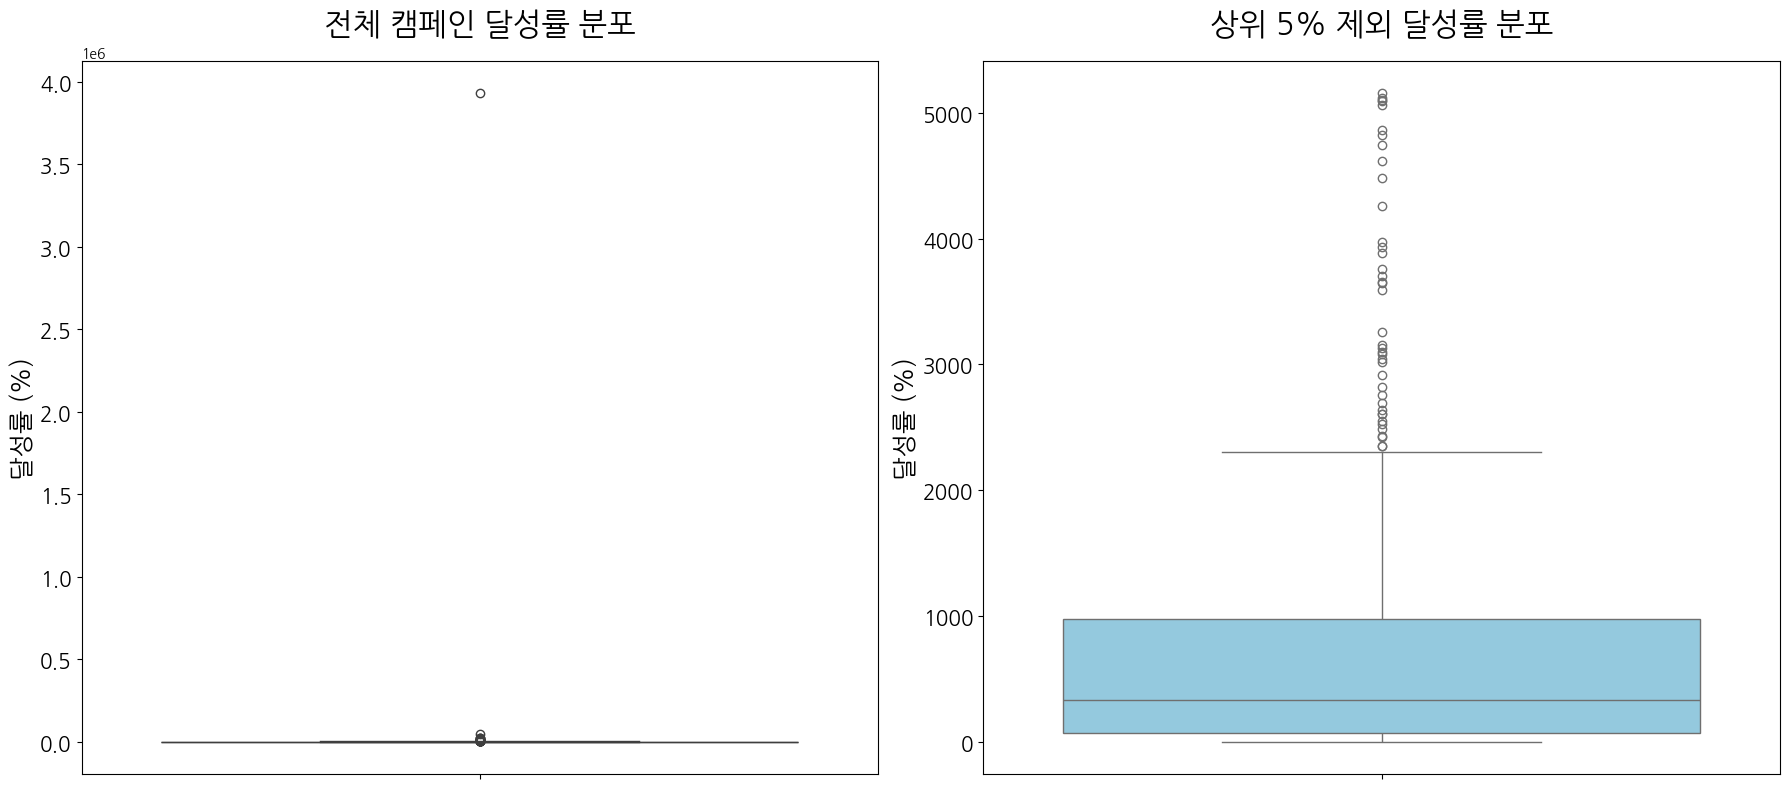

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.boxplot(y=df['achievement_rate'], ax=axes[0])
axes[0].set_title('전체 캠페인 달성률 분포', fontsize=22, pad=20)
axes[0].set_ylabel('달성률 (%)', fontsize=18)
axes[0].tick_params(labelsize=15)

df_trimmed = df[df['achievement_rate'] <= df['achievement_rate'].quantile(0.95)]
sns.boxplot(y=df_trimmed['achievement_rate'], ax=axes[1], color='skyblue')
axes[1].set_title('상위 5% 제외 달성률 분포', fontsize=22, pad=20)
axes[1].set_ylabel('달성률 (%)', fontsize=18)
axes[1].tick_params(labelsize=15)

plt.tight_layout()
plt.show()

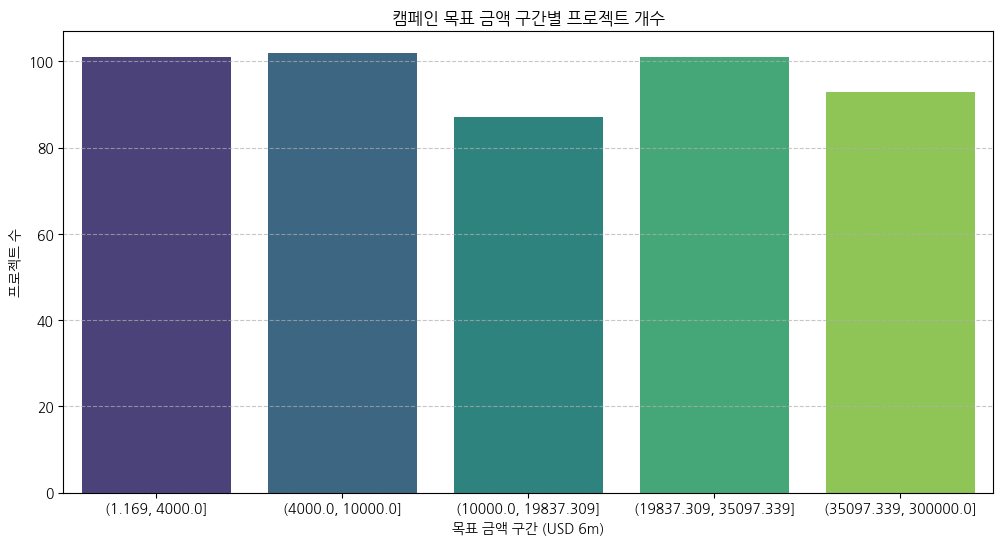

,goal_range,project_count
0,"(1.169, 4000.0]",101
1,"(4000.0, 10000.0]",102
2,"(10000.0, 19837.309]",87
3,"(19837.309, 35097.339]",101
4,"(35097.339, 300000.0]",93


In [14]:
# 구간별 프로젝트 개수 계산
goal_counts = df['goal_range'].value_counts().sort_index().reset_index()
goal_counts.columns = ['goal_range', 'project_count']

# 시각화
plt.figure(figsize=(12, 6))
sns.barplot(x='goal_range', y='project_count', data=goal_counts, palette='viridis', hue='goal_range', legend=False)

plt.title('캠페인 목표 금액 구간별 프로젝트 개수')
plt.xlabel('목표 금액 구간 (USD 6m)')
plt.ylabel('프로젝트 수')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 수치 데이터 출력
display(goal_counts)

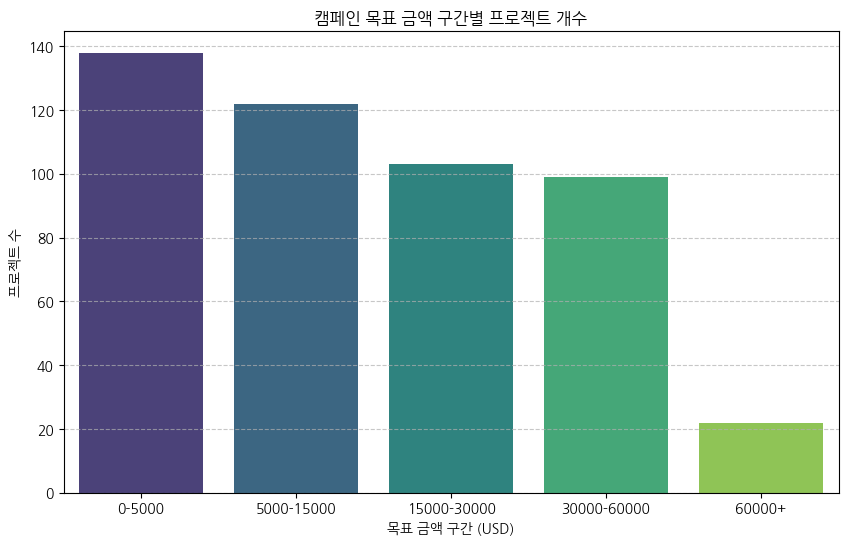

goal_range_clean
0-5000         138
5000-15000     122
15000-30000    103
30000-60000     99
60000+          22
Name: count, dtype: int64


In [15]:
import numpy as np

# 가독성을 위해 직접 구간 정의 (0~5k, 5k~15k, 15k~30k, 30k~60k, 60k~300k)
bins = [0, 5000, 15000, 30000, 60000, 300000]
labels = ['0-5000', '5000-15000', '15000-30000', '30000-60000', '60000+']

# 새로운 구간 적용
df['goal_range_clean'] = pd.cut(df['campaignGoal_usd_6m'], bins=bins, labels=labels)

# 시각화 (프로젝트 개수)
plt.figure(figsize=(10, 6))
sns.countplot(x='goal_range_clean', data=df, palette='viridis', hue='goal_range_clean', legend=False)

plt.title('캠페인 목표 금액 구간별 프로젝트 개수')
plt.xlabel('목표 금액 구간 (USD)')
plt.ylabel('프로젝트 수')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 구간별 개수 확인
print(df['goal_range_clean'].value_counts().sort_index())

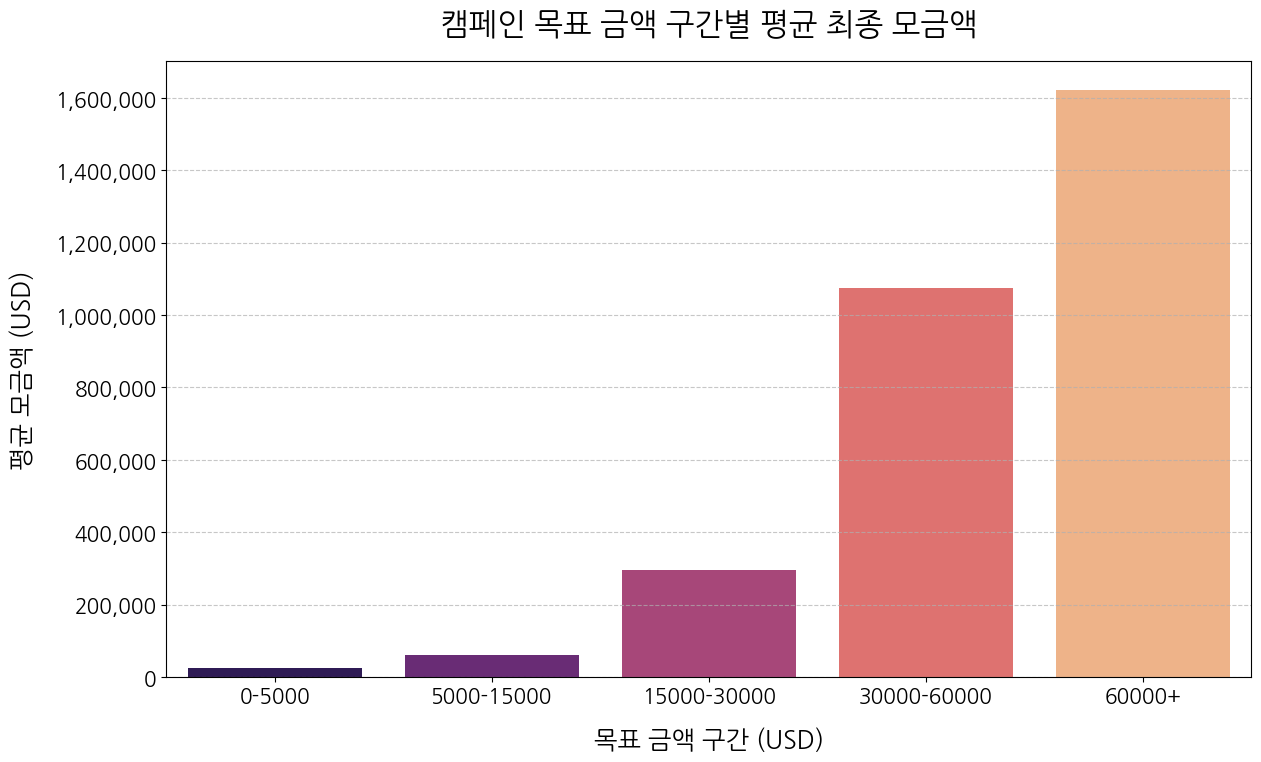

In [ ]:
plt.figure(figsize=(14, 8))
ax = sns.barplot(x='goal_range_clean', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None, palette='magma', hue='goal_range_clean', legend=False)

ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title('캠페인 목표 금액 구간별 평균 최종 모금액', fontsize=22, pad=20)
plt.xlabel('목표 금액 구간 (USD)', fontsize=18, labelpad=15)
plt.ylabel('평균 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

최종 모금액과 각 속성 간의 상관계수:
fundsGathered_usd_6m    1.000000
minAge                  0.158348
playTime                0.024015
maxPlayers             -0.038049
minPlayers             -0.192643
Name: fundsGathered_usd_6m, dtype: float64


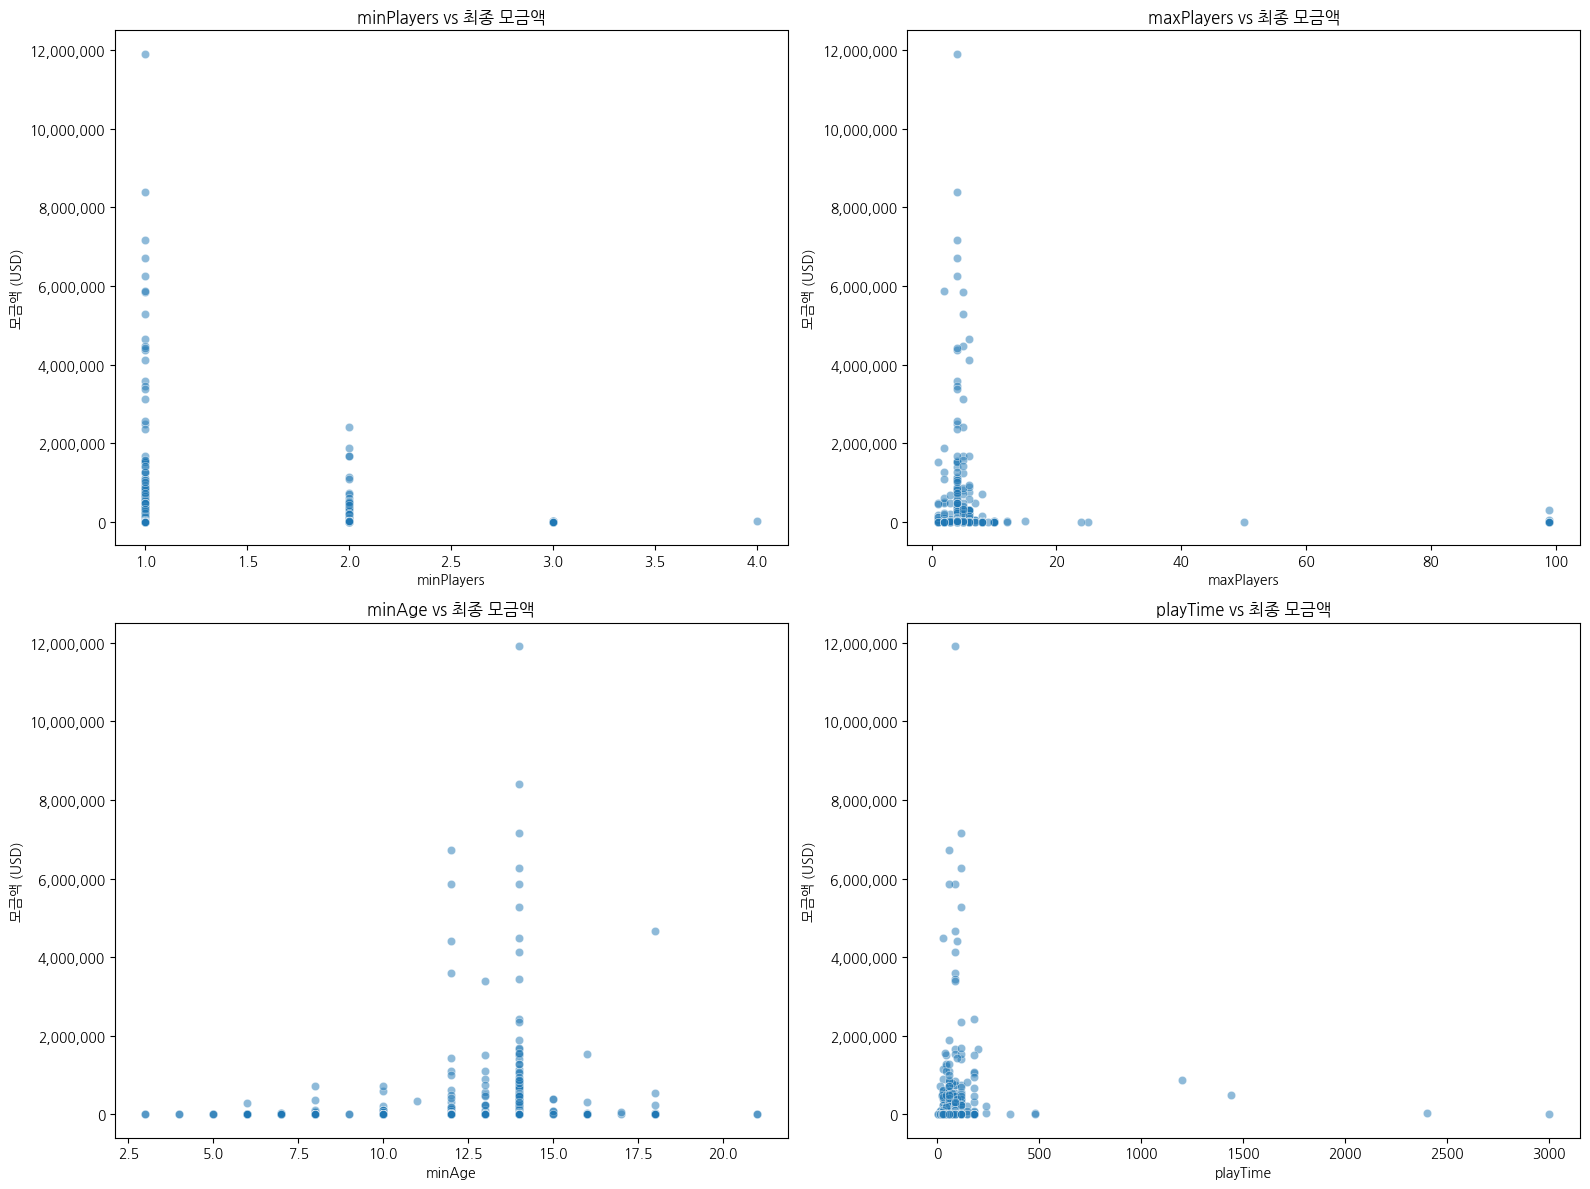

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 분석할 속성 리스트
features = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
target = 'fundsGathered_usd_1m'

# 상관계수 계산
correlations = df[features + [target]].corr()[target].sort_values(ascending=False)
print("최종 모금액과 각 속성 간의 상관계수:")
print(correlations)

# 시각화 (4개의 산점도)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.scatterplot(data=df, x=col, y=target, alpha=0.5, ax=axes[i])
    axes[i].set_title(f'{col} vs 최종 모금액')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('모금액 (USD)')
    # y축 콤마 형식 적용
    axes[i].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

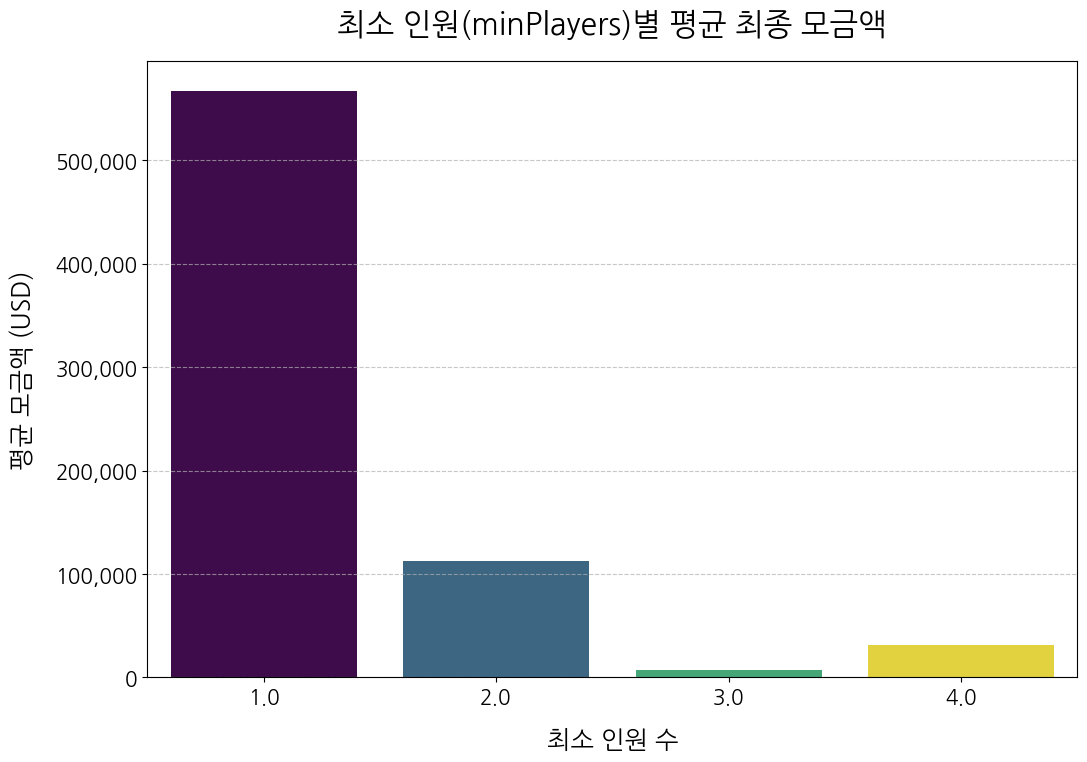

In [ ]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='minPlayers', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None, palette='viridis', hue='minPlayers', legend=False)

ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title('최소 인원(minPlayers)별 평균 최종 모금액', fontsize=22, pad=20)
plt.xlabel('최소 인원 수', fontsize=18, labelpad=15)
plt.ylabel('평균 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

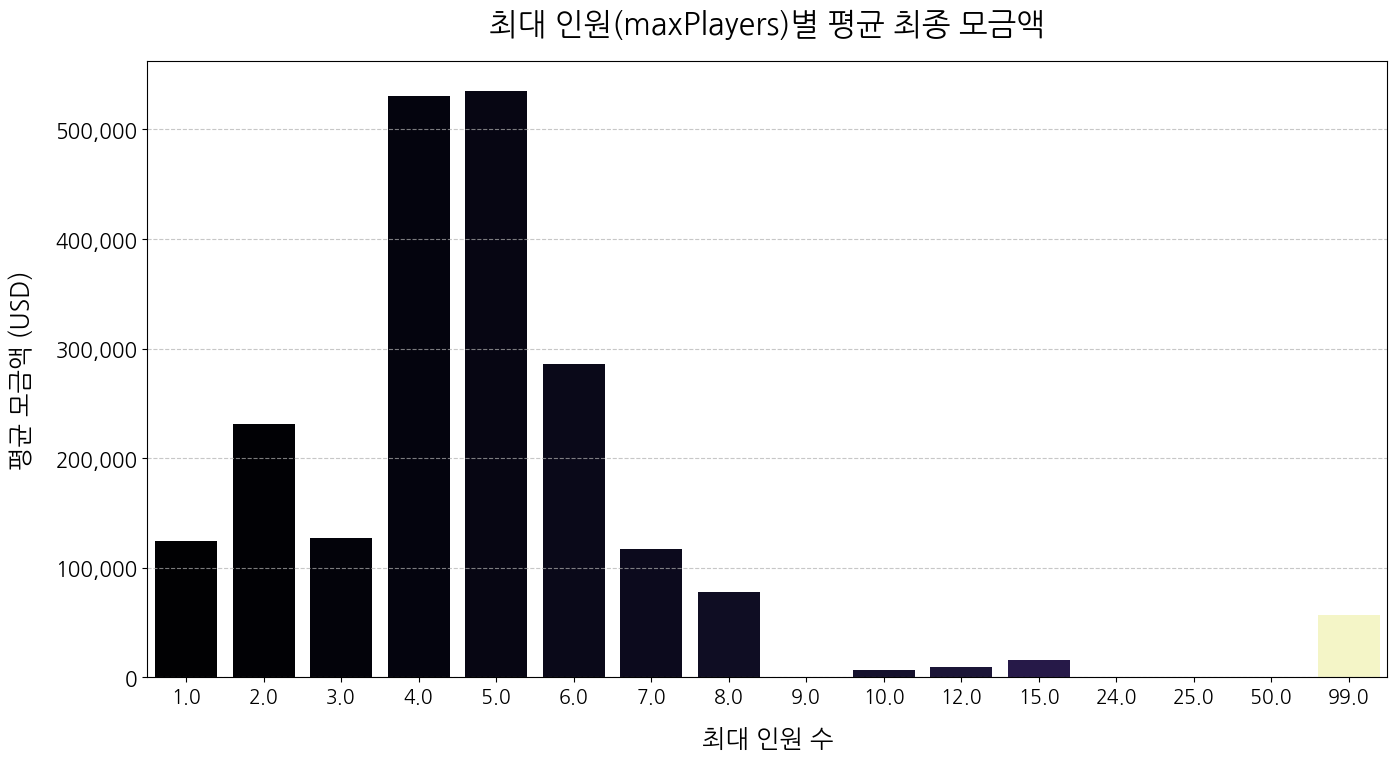

In [ ]:
plt.figure(figsize=(16, 8))
ax = sns.barplot(x='maxPlayers', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None, palette='magma', hue='maxPlayers', legend=False)

ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title('최대 인원(maxPlayers)별 평균 최종 모금액', fontsize=22, pad=20)
plt.xlabel('최대 인원 수', fontsize=18, labelpad=15)
plt.ylabel('평균 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

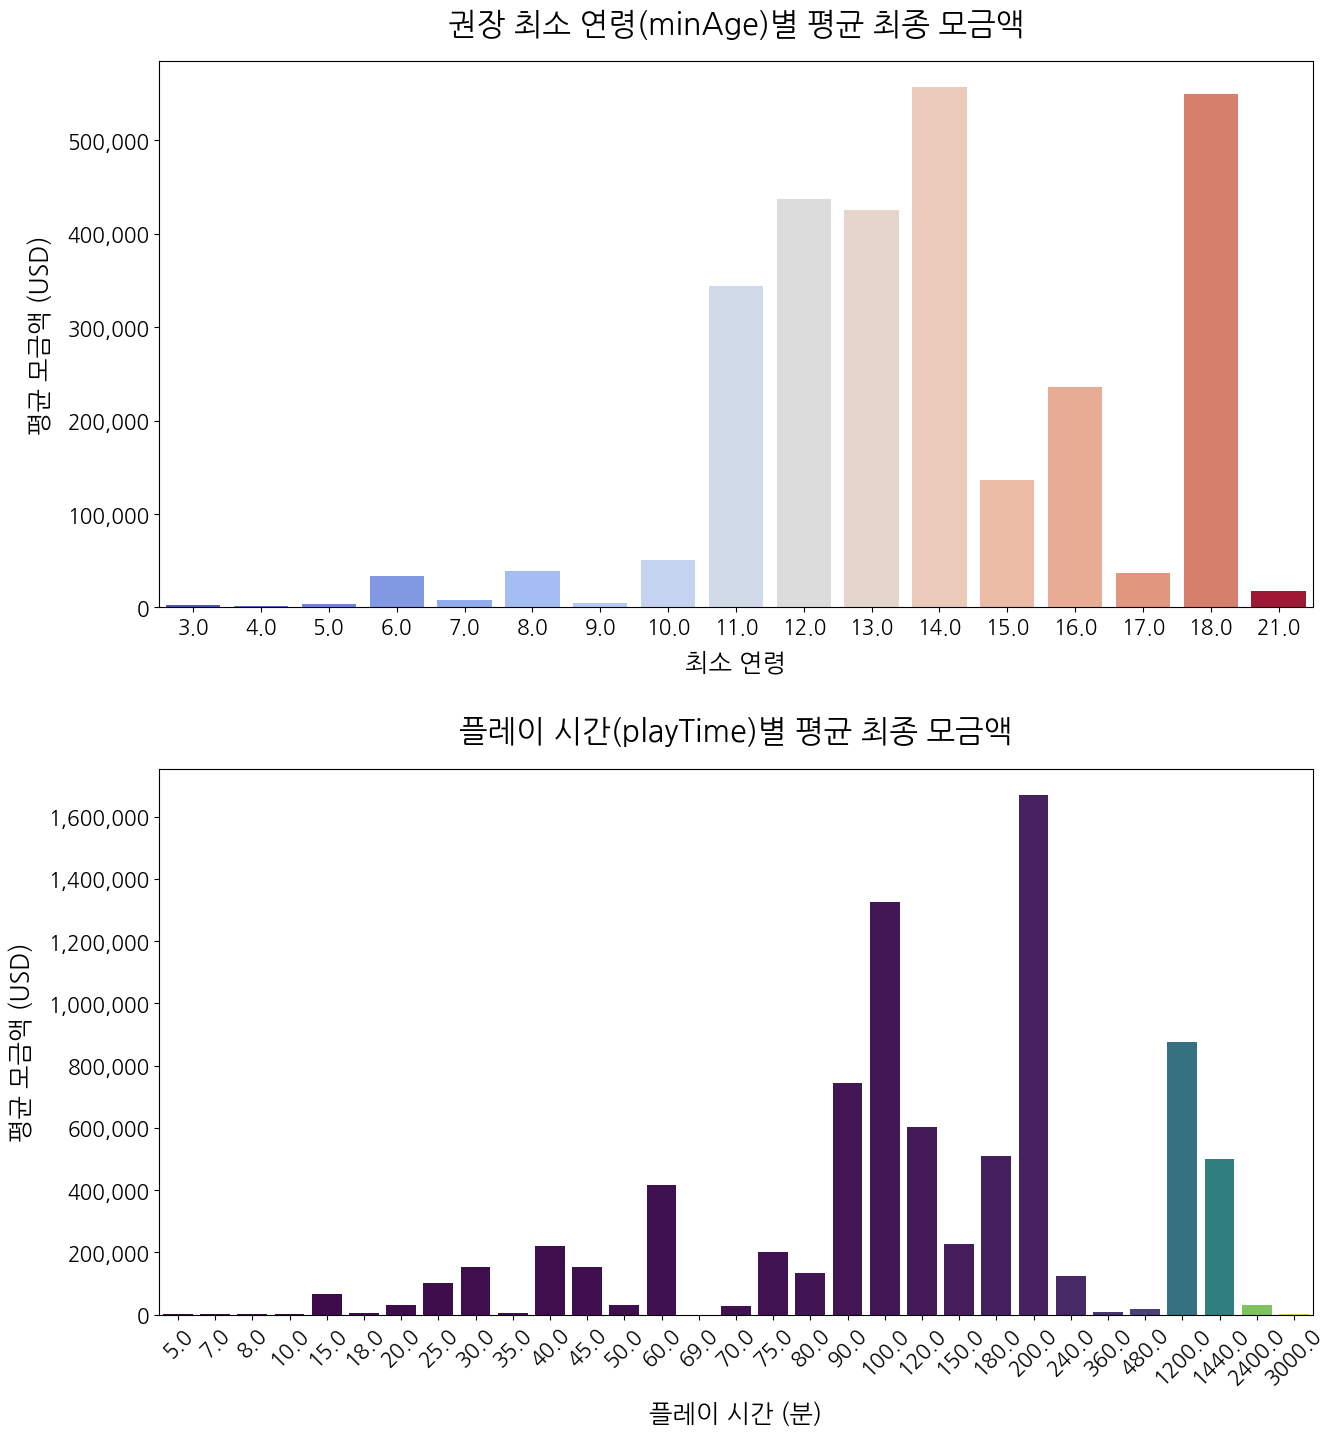

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(14, 15))

sns.barplot(x='minAge', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None, ax=axes[0], palette='coolwarm', hue='minAge', legend=False)
axes[0].set_title('권장 최소 연령(minAge)별 평균 최종 모금액', fontsize=22, pad=20)
axes[0].set_xlabel('최소 연령', fontsize=18, labelpad=10)
axes[0].set_ylabel('평균 모금액 (USD)', fontsize=18, labelpad=10)
axes[0].tick_params(axis='both', labelsize=15)
axes[0].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

sns.barplot(x='playTime', y='fundsGathered_usd_1m', data=df, estimator='mean', errorbar=None, ax=axes[1], palette='viridis', hue='playTime', legend=False)
axes[1].set_title('플레이 시간(playTime)별 평균 최종 모금액', fontsize=22, pad=20)
axes[1].set_xlabel('플레이 시간 (분)', fontsize=18, labelpad=10)
axes[1].set_ylabel('평균 모금액 (USD)', fontsize=18, labelpad=10)
axes[1].tick_params(axis='both', labelsize=15)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.setp(axes[1].get_xticklabels(), rotation=45)

plt.tight_layout(pad=3.0)
plt.show()

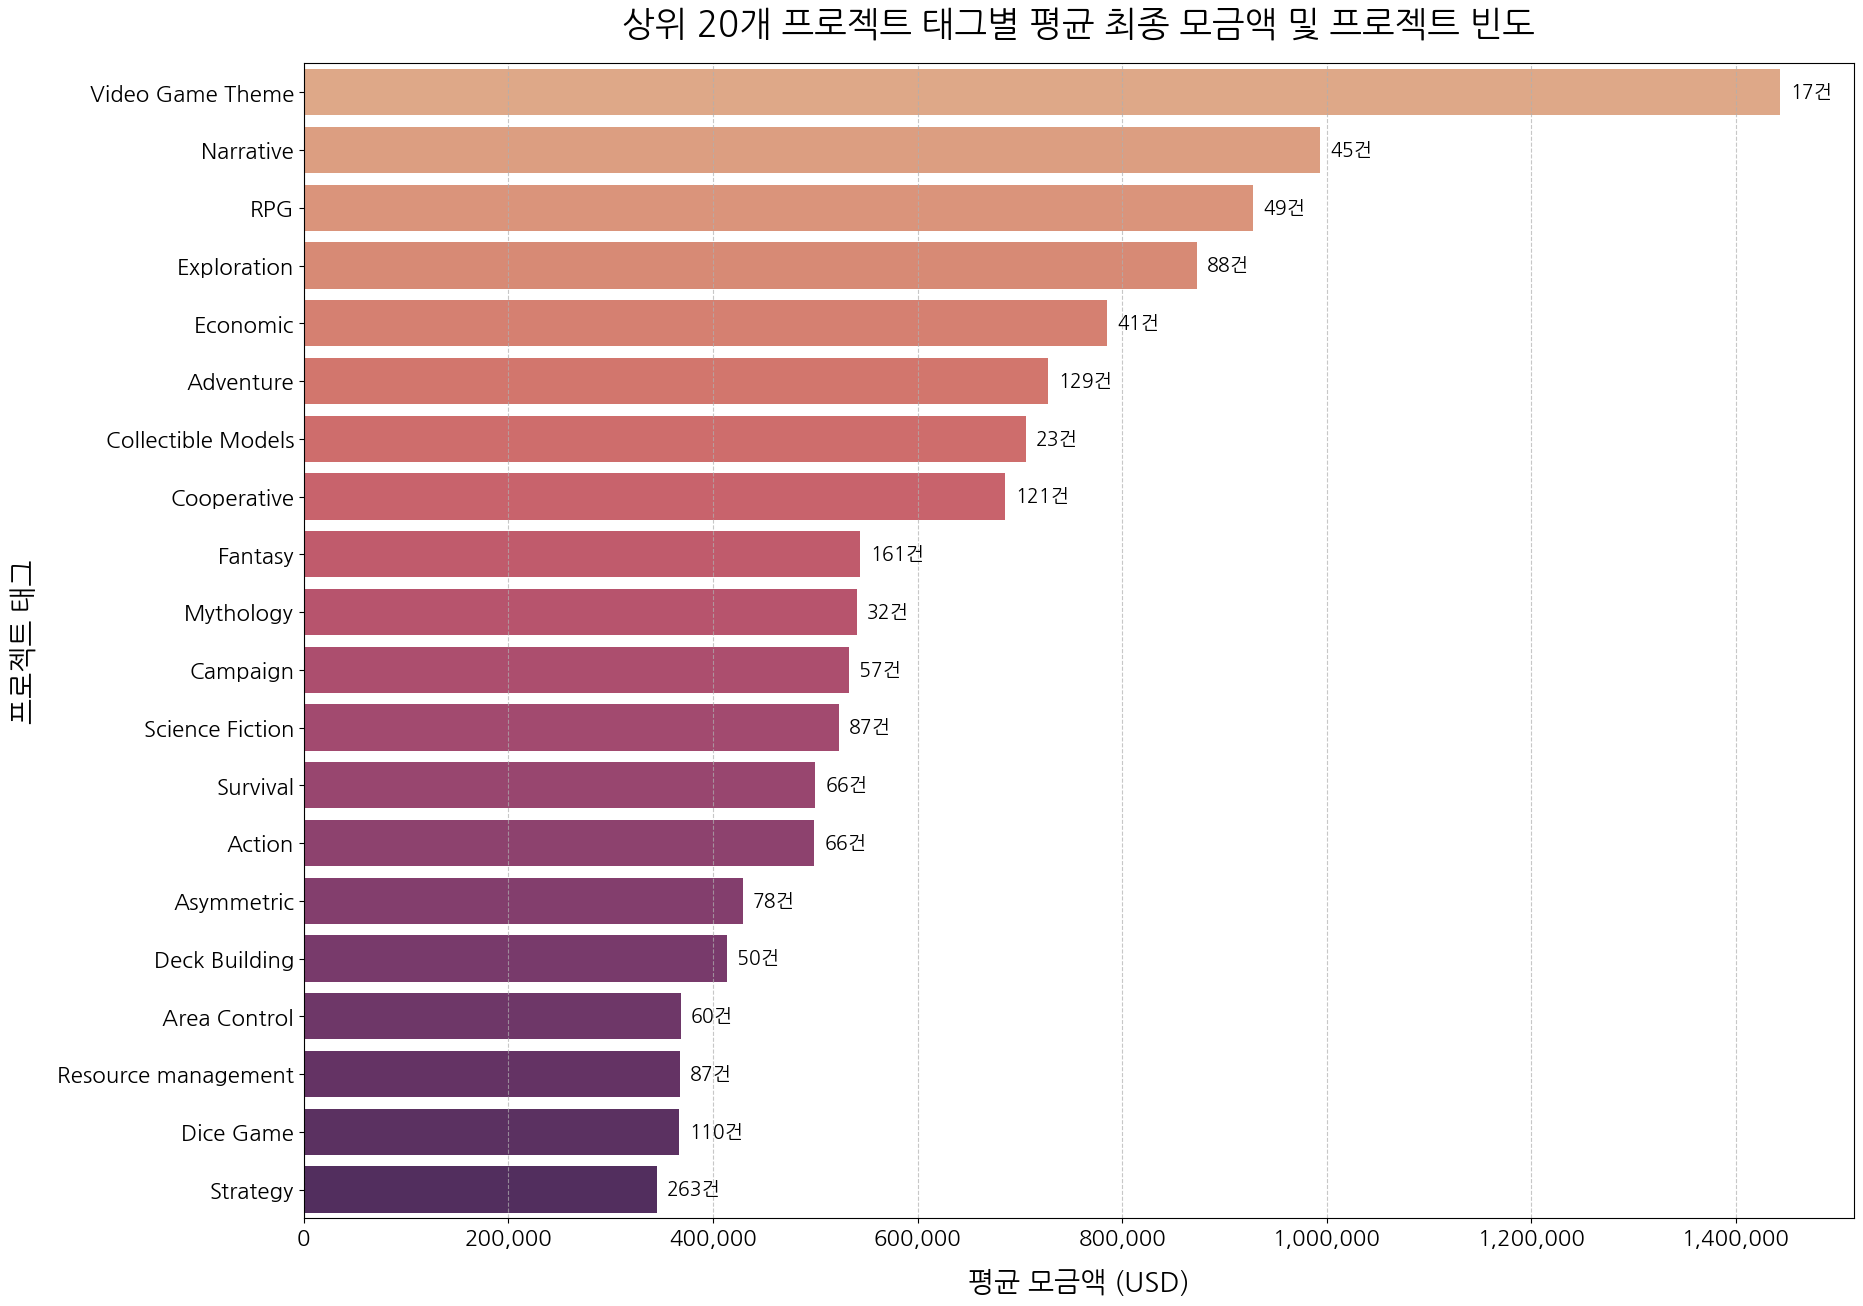

상위 10개 고수익 태그 상세:


,tag_list,avg_funds,count
58,Video Game Theme,1.443026e+06,17
39,Narrative,9.932934e+05,45
45,RPG,9.275699e+05,49
22,Exploration,8.726726e+05,88
20,Economic,7.852451e+05,41
4,Adventure,7.273332e+05,129
12,Collectible Models,7.057485e+05,23
14,Cooperative,6.855386e+05,121
24,Fantasy,5.434956e+05,161
38,Mythology,5.406856e+05,32


In [ ]:
import ast
import matplotlib.pyplot as plt
import seaborn as sns

# projectTags가 문자열 형태의 리스트일 경우를 대비해 변환
def parse_tags(tag_str):
    try:
        return ast.literal_eval(tag_str)
    except:
        return [t.strip() for t in str(tag_str).split(',')]

# 태그 데이터 전처리
df_tags = df.copy()
df_tags['tag_list'] = df_tags['projectTags'].apply(parse_tags)
df_exploded = df_tags.explode('tag_list')

# 태그별 평균 모금액 및 프로젝트 수 계산
tag_analysis = df_exploded.groupby('tag_list').agg(
    avg_funds=('fundsGathered_usd_1m', 'mean'),
    count=('projectID', 'count')
).reset_index()

tag_analysis_filtered = tag_analysis[tag_analysis['count'] >= 5].sort_values(by='avg_funds', ascending=False)

# 시각화 설정
plt.figure(figsize=(20, 15))
ax = sns.barplot(x='avg_funds', y='tag_list', data=tag_analysis_filtered.head(20), palette='flare', hue='tag_list', legend=False)

# 막대 끝에 빈도(count) 표시
for i, p in enumerate(ax.patches):
    width = p.get_width()
    count = tag_analysis_filtered.iloc[i]['count']
    ax.text(width + 10000, p.get_y() + p.get_height()/2, f'{int(count)}건', va='center', fontsize=14)

# x축 천 단위 콤마 설정
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 폰트 크기 조정
plt.title('상위 20개 프로젝트 태그별 평균 최종 모금액 및 프로젝트 빈도', fontsize=25, pad=20)
plt.xlabel('평균 모금액 (USD)', fontsize=20, labelpad=15)
plt.ylabel('프로젝트 태그', fontsize=20, labelpad=15)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 상세 데이터 출력
print("상위 10개 고수익 태그 상세:")
display(tag_analysis_filtered.head(10))

In [22]:
import ast

# 태그 데이터를 처리하기 위한 함수 정의
def parse_tags(tag_str):
    try:
        return ast.literal_eval(tag_str)
    except:
        return [t.strip() for t in str(tag_str).split(',')]

# 데이터프레임 복사 및 태그 리스트 전처리
df_tags = df.copy()
df_tags['tag_list'] = df_tags['projectTags'].apply(parse_tags)
df_exploded = df_tags.explode('tag_list')

# 고유 태그 개수 확인
unique_tags_count = df_exploded['tag_list'].nunique()
print(f"총 고유 태그 개수: {unique_tags_count}개")

총 고유 태그 개수: 63개


목표 달성 시간(초)과 최종 모금액 간의 상관계수: -0.1138


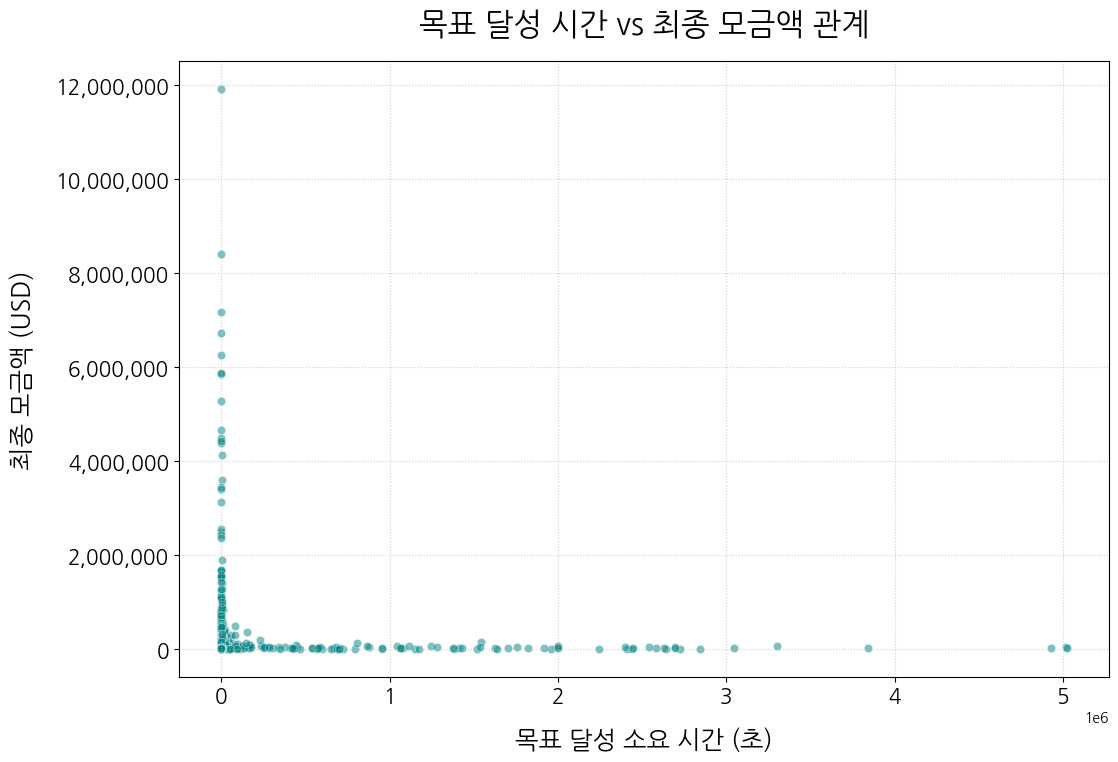

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# fundedInSeconds와 최종 모금액 간의 상관계수 계산
correlation_speed = df['fundedInSeconds'].corr(df['fundsGathered_usd_1m'])
print(f"목표 달성 시간(초)과 최종 모금액 간의 상관계수: {correlation_speed:.4f}")

# 시각화 (산점도)
plt.figure(figsize=(12, 8))
sns.scatterplot(x='fundedInSeconds', y='fundsGathered_usd_1m', data=df, alpha=0.5, color='teal')

# 폰트 크기 및 포맷 설정
plt.title('목표 달성 시간 vs 최종 모금액 관계', fontsize=22, pad=20)
plt.xlabel('목표 달성 소요 시간 (초)', fontsize=18, labelpad=15)
plt.ylabel('최종 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# y축 콤마 형식
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

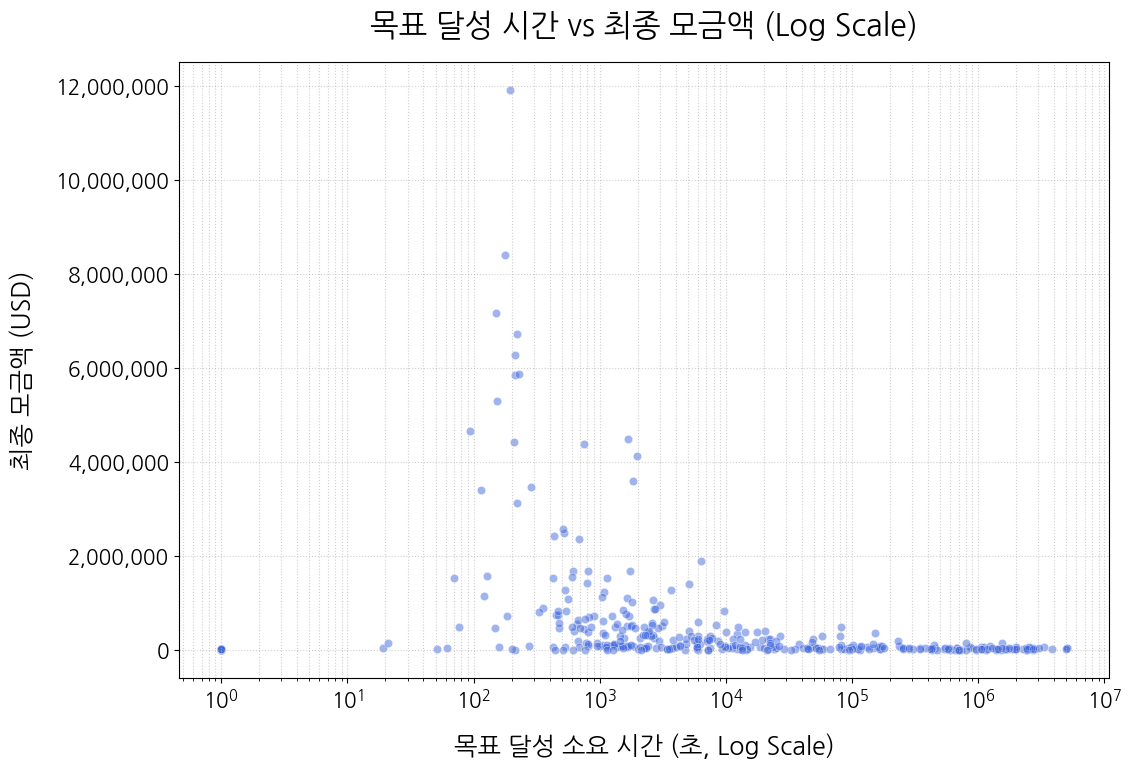

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 0 또는 음수 값이 있을 수 있으므로 (로그 변환을 위해) 1초를 더해줍니다.
df['fundedInSeconds_log'] = df['fundedInSeconds'] + 1

plt.figure(figsize=(12, 8))
sns.scatterplot(x='fundedInSeconds_log', y='fundsGathered_usd_1m', data=df, alpha=0.5, color='royalblue')

# X축에 로그 스케일 적용
plt.xscale('log')

# 폰트 크기 및 포맷 설정
plt.title('목표 달성 시간 vs 최종 모금액 (Log Scale)', fontsize=22, pad=20)
plt.xlabel('목표 달성 소요 시간 (초, Log Scale)', fontsize=18, labelpad=15)
plt.ylabel('최종 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# y축 콤마 형식
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.show()

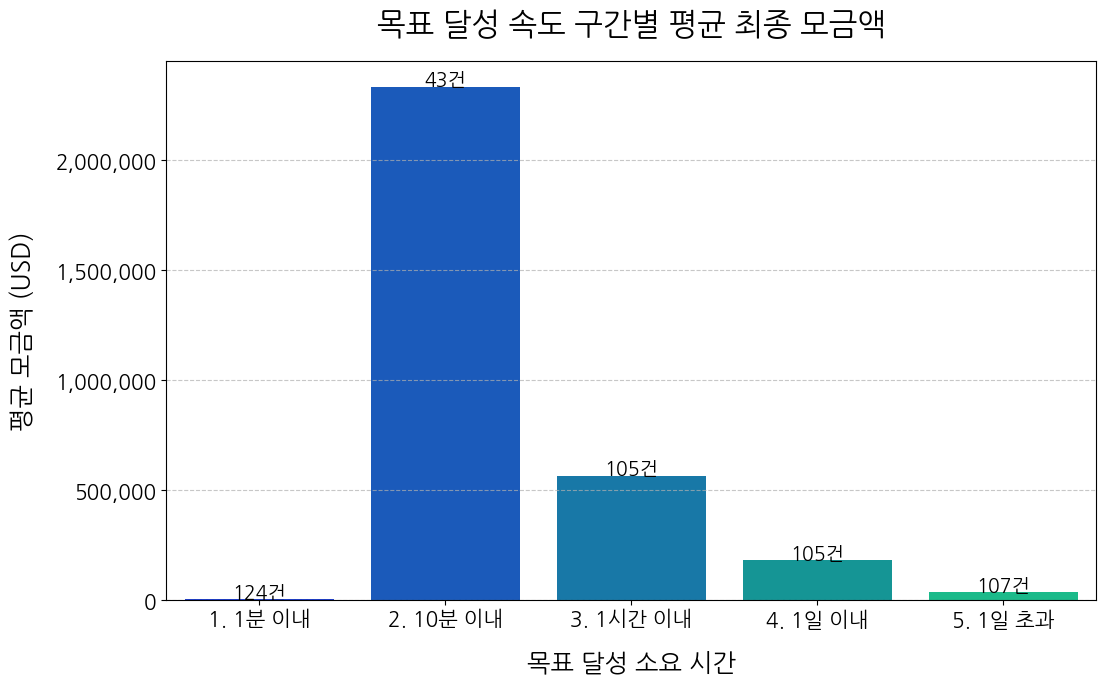

,funding_speed_category,avg_funds,project_count
0,1. 1분 이내,4.663144e+03,124
1,2. 10분 이내,2.334839e+06,43
2,3. 1시간 이내,5.664064e+05,105
3,4. 1일 이내,1.807348e+05,105
4,5. 1일 초과,3.522739e+04,107


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 시간을 의미 있는 구간으로 나누기
def categorize_time(seconds):
    if seconds <= 60:
        return '1. 1분 이내'
    elif seconds <= 600:
        return '2. 10분 이내'
    elif seconds <= 3600:
        return '3. 1시간 이내'
    elif seconds <= 86400:
        return '4. 1일 이내'
    else:
        return '5. 1일 초과'

df['funding_speed_category'] = df['fundedInSeconds'].apply(categorize_time)

# 구간별 프로젝트 수와 평균 모금액 계산
speed_analysis = df.groupby('funding_speed_category').agg(
    avg_funds=('fundsGathered_usd_1m', 'mean'),
    project_count=('projectID', 'count')
).reset_index()

# 시각화
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='funding_speed_category', y='avg_funds', data=speed_analysis, palette='winter', hue='funding_speed_category', legend=False)

# y축 콤마 형식
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 막대 위에 프로젝트 건수 표시
for i, p in enumerate(ax.patches):
    count = speed_analysis.iloc[i]['project_count']
    ax.text(p.get_x() + p.get_width()/2., p.get_height() + 5000, f'{int(count)}건', ha='center', fontsize=14)

plt.title('목표 달성 속도 구간별 평균 최종 모금액', fontsize=22, pad=20)
plt.xlabel('목표 달성 소요 시간', fontsize=18, labelpad=15)
plt.ylabel('평균 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

display(speed_analysis)

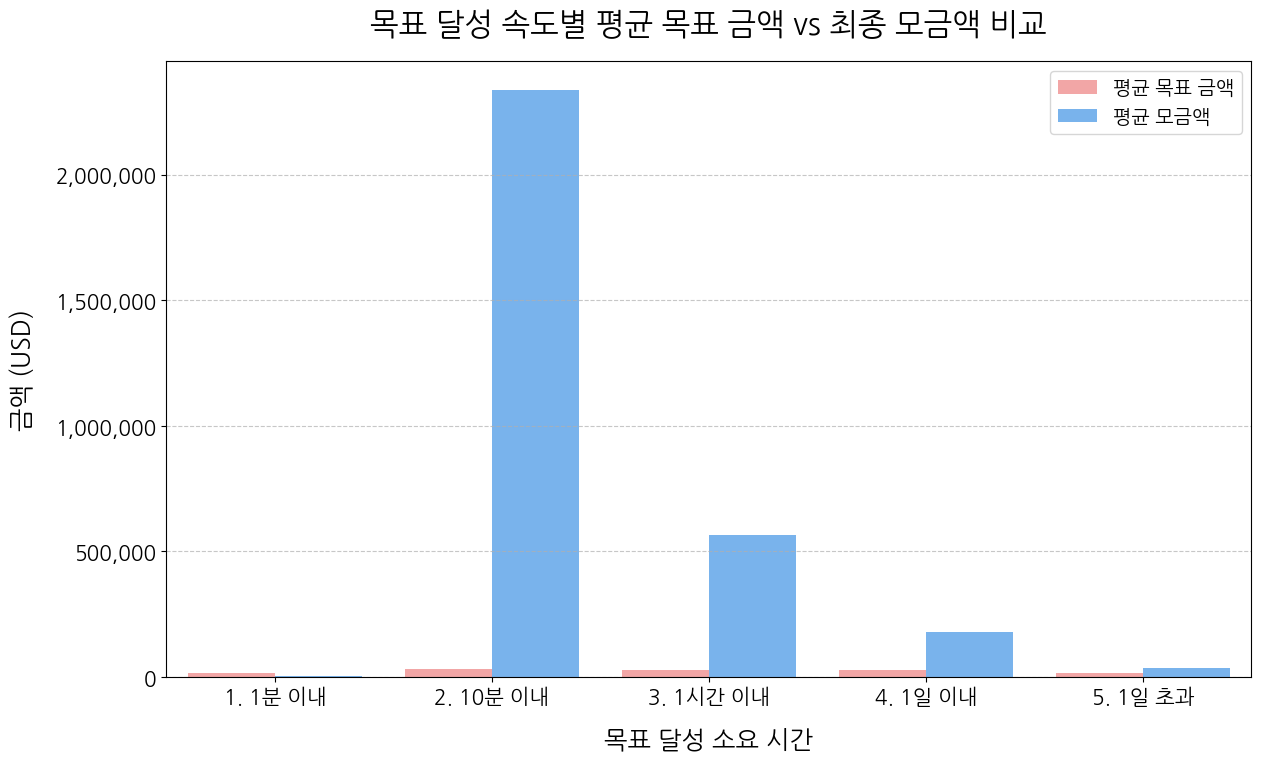

In [ ]:
# 속도 구간별 평균 목표 금액 vs 실제 모금액 비교
speed_goal_analysis = df.groupby('funding_speed_category').agg(
    avg_goal=('campaignGoal_usd_6m', 'mean'),
    avg_funds=('fundsGathered_usd_1m', 'mean')
).reset_index()

# 데이터 재구조화 (Melting) 하여 시각화
speed_melted = speed_goal_analysis.melt(id_vars='funding_speed_category', var_name='Metric', value_name='Amount')
speed_melted['Metric'] = speed_melted['Metric'].map({'avg_goal': '평균 목표 금액', 'avg_funds': '평균 모금액'})

plt.figure(figsize=(14, 8))
sns.barplot(x='funding_speed_category', y='Amount', hue='Metric', data=speed_melted, palette=['#ff9999','#66b3ff'])

# y축 콤마 형식
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title('목표 달성 속도별 평균 목표 금액 vs 최종 모금액 비교', fontsize=22, pad=20)
plt.xlabel('목표 달성 소요 시간', fontsize=18, labelpad=15)
plt.ylabel('금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

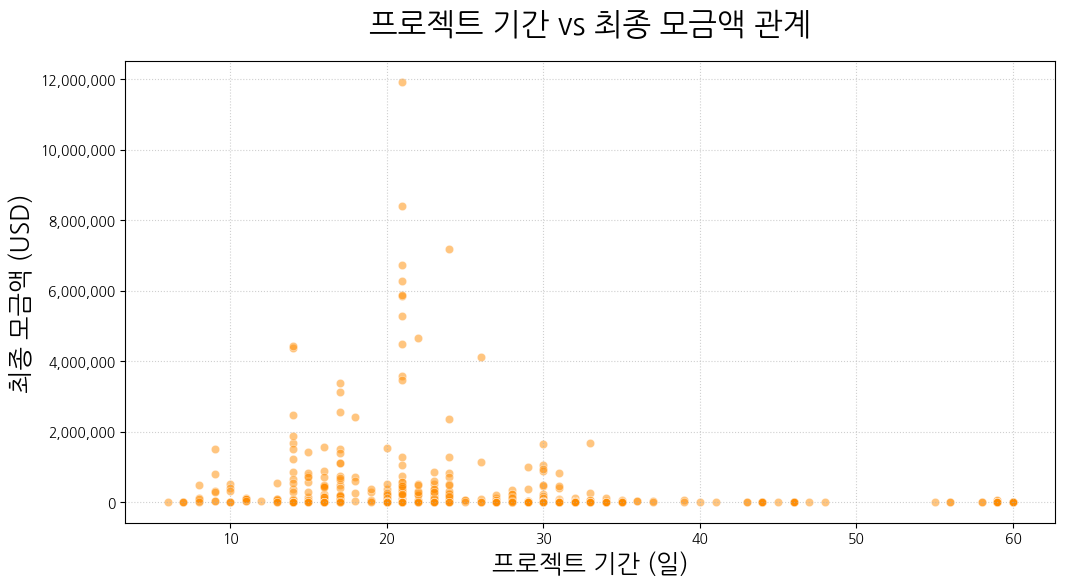

프로젝트 기간과 최종 모금액 간의 상관계수: -0.1423


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 산점도 및 상관계수 확인
plt.figure(figsize=(12, 6))
sns.scatterplot(x='duration_days', y='fundsGathered_usd_1m', data=df, alpha=0.5, color='darkorange')

plt.title('프로젝트 기간 vs 최종 모금액 관계', fontsize=22, pad=20)
plt.xlabel('프로젝트 기간 (일)', fontsize=18)
plt.ylabel('최종 모금액 (USD)', fontsize=18)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

corr_duration = df['duration_days'].corr(df['fundsGathered_usd_1m'])
print(f"프로젝트 기간과 최종 모금액 간의 상관계수: {corr_duration:.4f}")

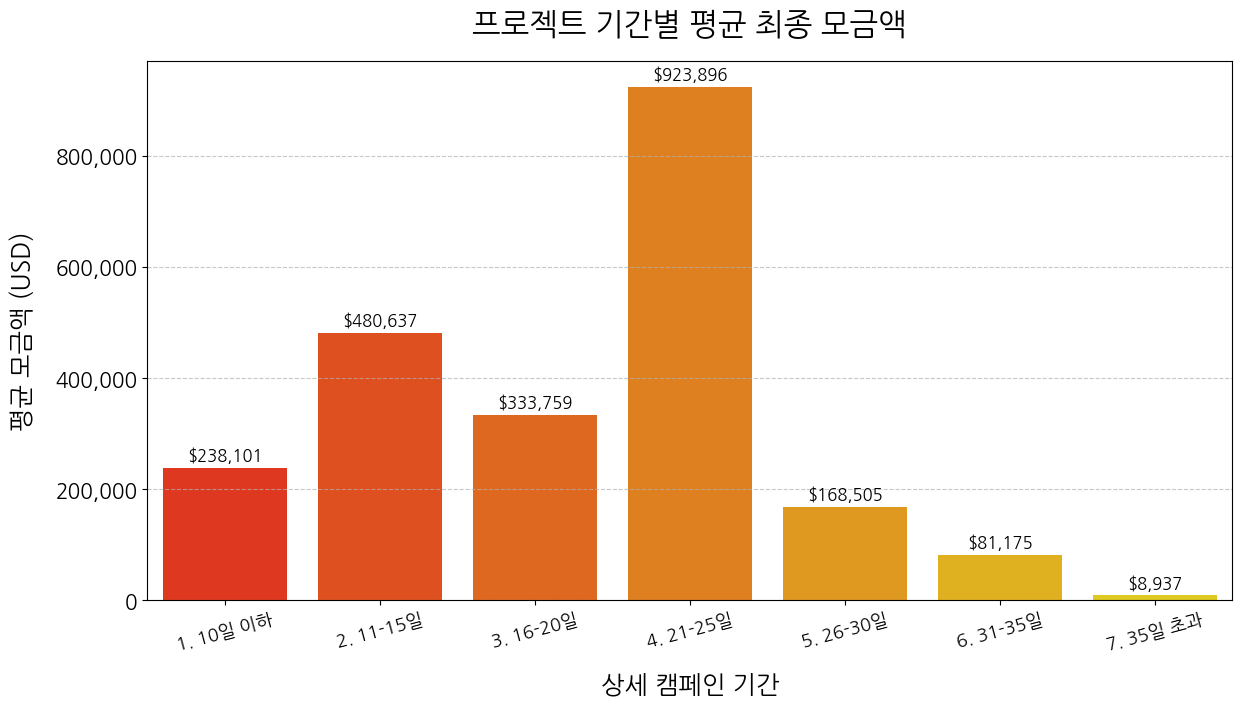

,duration_category_detailed,count
0,1. 10일 이하,21
1,2. 11-15일,56
2,3. 16-20일,103
3,4. 21-25일,104
4,5. 26-30일,93
5,6. 31-35일,58
6,7. 35일 초과,49


In [ ]:
# 2. 기간을 더 세분화하여 구간별 평균 모금액 비교 (5~10일 단위)
def categorize_duration_finer(days):
    if days <= 10: return '1. 10일 이하'
    elif days <= 15: return '2. 11-15일'
    elif days <= 20: return '3. 16-20일'
    elif days <= 25: return '4. 21-25일'
    elif days <= 30: return '5. 26-30일'
    elif days <= 35: return '6. 31-35일'
    else: return '7. 35일 초과'

df['duration_category_detailed'] = df['duration_days'].apply(categorize_duration_finer)

duration_detailed_analysis = df.groupby('duration_category_detailed')['fundsGathered_usd_1m'].mean().reset_index()

plt.figure(figsize=(14, 7))
ax = sns.barplot(x='duration_category_detailed', y='fundsGathered_usd_1m', data=duration_detailed_analysis, palette='autumn', hue='duration_category_detailed', legend=False)

# y축 천 단위 콤마
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 막대 위에 수치 표시
for p in ax.patches:
    ax.annotate(f'${int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title('프로젝트 기간별 평균 최종 모금액', fontsize=22, pad=20)
plt.xlabel('상세 캠페인 기간', fontsize=18, labelpad=15)
plt.ylabel('평균 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=13, rotation=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 구간별 데이터 개수도 함께 확인
display(df['duration_category_detailed'].value_counts().sort_index().reset_index(name='count'))

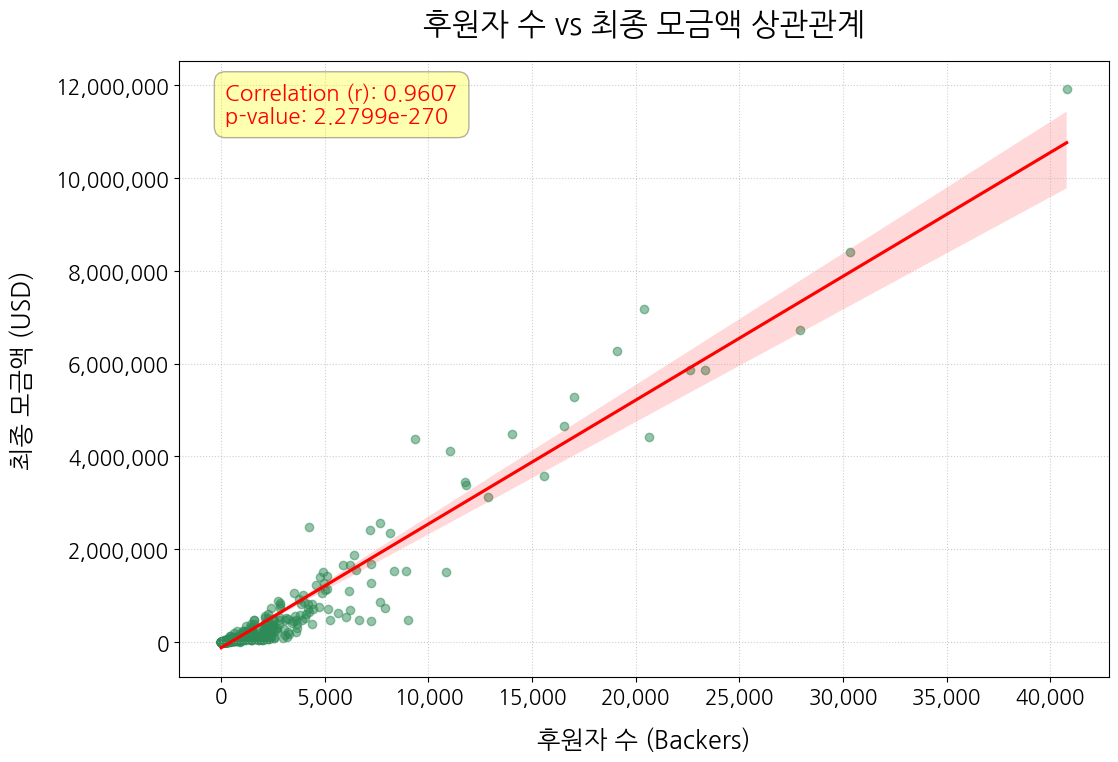

후원자 수와 최종 모금액 간의 상관계수: 0.9607
p-value: 2.2799e-270
전체 프로젝트의 1인당 평균 후원 금액(ARPU): $120.06


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 상관계수 및 p-value 계산
slope, intercept, r_value, p_value, std_err = stats.linregress(df['backersCount'], df['fundsGathered_usd_1m'])

plt.figure(figsize=(12, 8))
sns.regplot(x='backersCount', y='fundsGathered_usd_1m', data=df,
            scatter_kws={'alpha':0.5, 'color':'seagreen'},
            line_kws={'color':'red'})

# 그래프 내부에 상관계수와 p-value 표시
plt.annotate(f'Correlation (r): {r_value:.4f}\np-value: {p_value:.4e}',
             xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=16, fontweight='bold', color='red',
             bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.3))

plt.title('후원자 수 vs 최종 모금액 상관관계', fontsize=22, pad=20)
plt.xlabel('후원자 수 (Backers)', fontsize=18, labelpad=15)
plt.ylabel('최종 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 천 단위 콤마 포맷
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 1인당 평균 후원 금액 계산 (Average Revenue Per User)
df['arpu'] = df['fundsGathered_usd_1m'] / df['backersCount']

print(f"후원자 수와 최종 모금액 간의 상관계수: {r_value:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"전체 프로젝트의 1인당 평균 후원 금액(ARPU): ${df['arpu'].mean():.2f}")

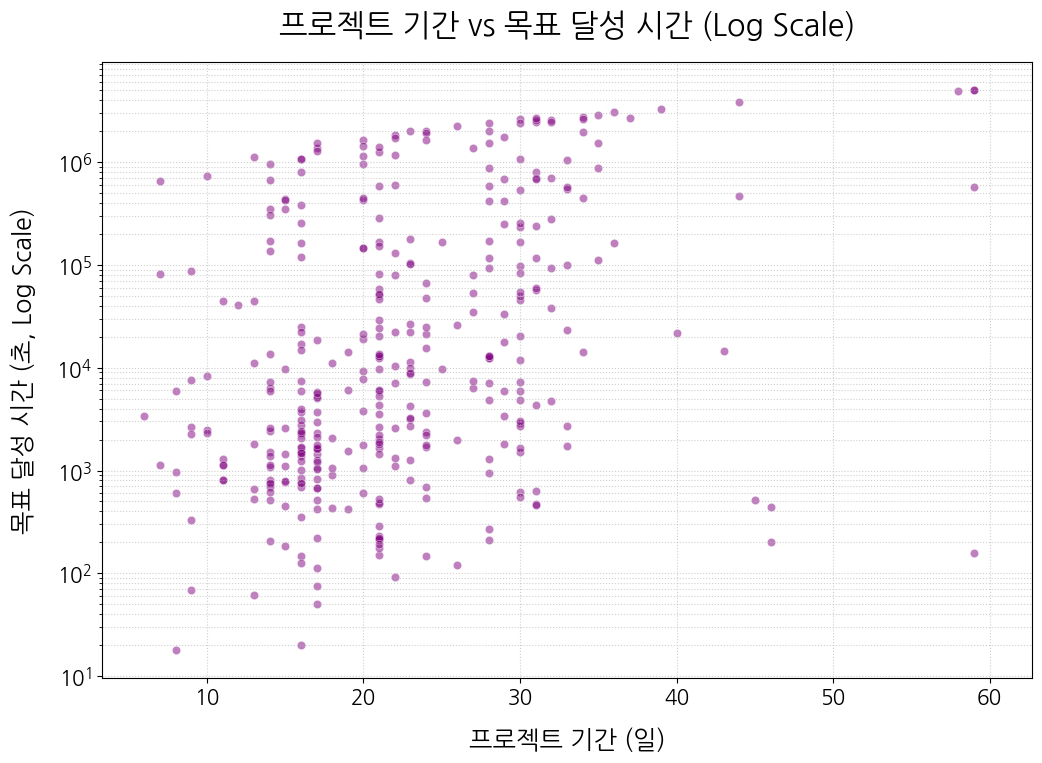

프로젝트 기간과 목표 달성 시간 간의 상관계수: 0.2119


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 로그 변환을 위한 데이터 준비 (0값 처리)
df['fundedInSeconds_log'] = np.log10(df['fundedInSeconds'] + 1)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='duration_days', y='fundedInSeconds', data=df, alpha=0.5, color='purple')

# Y축에 로그 스케일 적용하여 분포를 더 명확히 확인
plt.yscale('log')

plt.title('프로젝트 기간 vs 목표 달성 시간 (Log Scale)', fontsize=22, pad=20)
plt.xlabel('프로젝트 기간 (일)', fontsize=18, labelpad=15)
plt.ylabel('목표 달성 시간 (초, Log Scale)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.grid(True, which="both", linestyle=':', alpha=0.6)
plt.show()

# 상관계수 계산
corr_speed_duration = df['duration_days'].corr(df['fundedInSeconds'])
print(f"프로젝트 기간과 목표 달성 시간 간의 상관계수: {corr_speed_duration:.4f}")

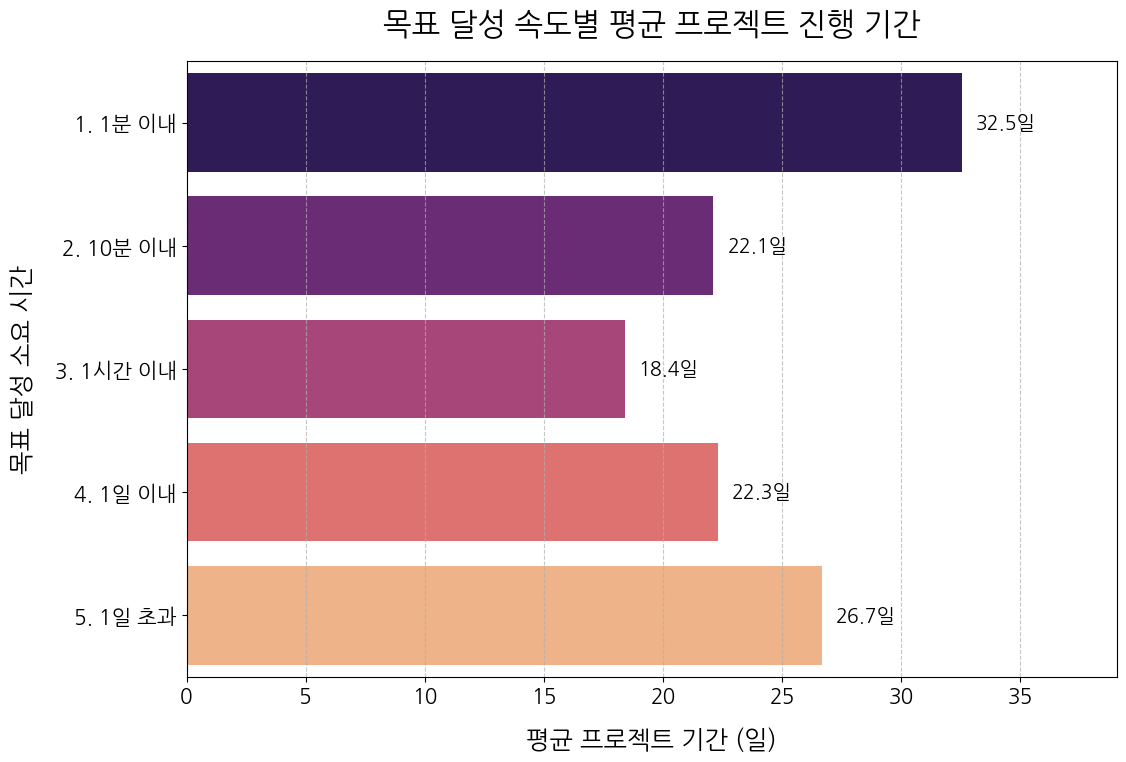

In [31]:
# 목표 달성 속도 구간별 평균 프로젝트 기간 분석 (X, Y축 반전)
speed_duration_analysis = df.groupby('funding_speed_category')['duration_days'].mean().reset_index()

plt.figure(figsize=(12, 8))
# x와 y를 바꾸어 가로 막대 그래프로 생성
ax = sns.barplot(x='duration_days', y='funding_speed_category', data=speed_duration_analysis, palette='magma', hue='funding_speed_category', legend=False)

# 막대 오른쪽에 평균 일수 표시
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}일',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(10, 0),
                textcoords='offset points',
                fontsize=14)

plt.title('목표 달성 속도별 평균 프로젝트 진행 기간', fontsize=22, pad=20)
plt.xlabel('평균 프로젝트 기간 (일)', fontsize=18, labelpad=15)
plt.ylabel('목표 달성 소요 시간', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(0, max(speed_duration_analysis['duration_days']) * 1.2)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

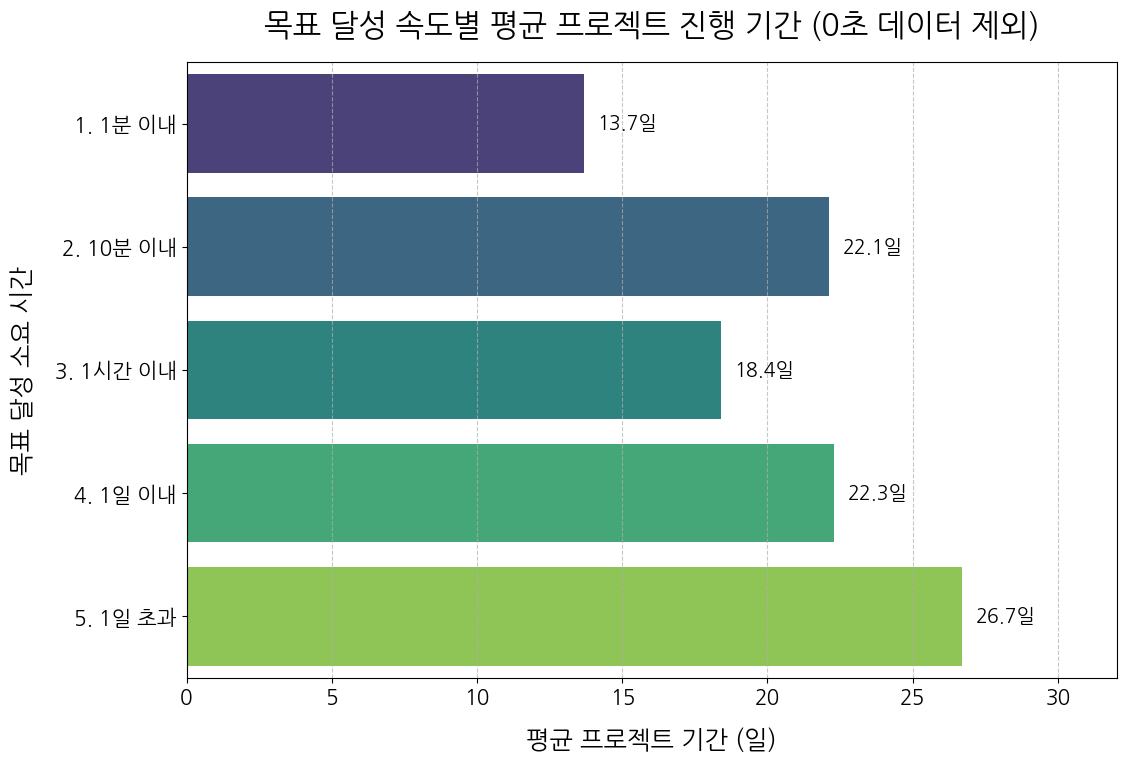

분석에서 제외된 데이터(fundedInSeconds == 0): 121건


,funding_speed_category,duration_days
0,1. 1분 이내,13.666667
1,2. 10분 이내,22.116279
2,3. 1시간 이내,18.390476
3,4. 1일 이내,22.295238
4,5. 1일 초과,26.682243


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 목표 달성 시간(fundedInSeconds)이 0보다 큰 데이터만 필터링
df_valid_speed = df[df['fundedInSeconds'] > 0].copy()

# 2. 필터링된 데이터를 바탕으로 목표 달성 속도 구간별 평균 프로젝트 기간 분석
speed_duration_analysis_filtered = df_valid_speed.groupby('funding_speed_category')['duration_days'].mean().reset_index()

plt.figure(figsize=(12, 8))
# 가로 막대 그래프 생성
ax = sns.barplot(x='duration_days', y='funding_speed_category', data=speed_duration_analysis_filtered, palette='viridis', hue='funding_speed_category', legend=False)

# 막대 오른쪽에 평균 일수 표시
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1f}일',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(10, 0),
                textcoords='offset points',
                fontsize=14)

plt.title('목표 달성 속도별 평균 프로젝트 진행 기간 (0초 데이터 제외)', fontsize=22, pad=20)
plt.xlabel('평균 프로젝트 기간 (일)', fontsize=18, labelpad=15)
plt.ylabel('목표 달성 소요 시간', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim(0, max(speed_duration_analysis_filtered['duration_days']) * 1.2)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# 제외된 데이터 수 확인
excluded_count = len(df) - len(df_valid_speed)
print(f"분석에서 제외된 데이터(fundedInSeconds == 0): {excluded_count}건")
display(speed_duration_analysis_filtered)

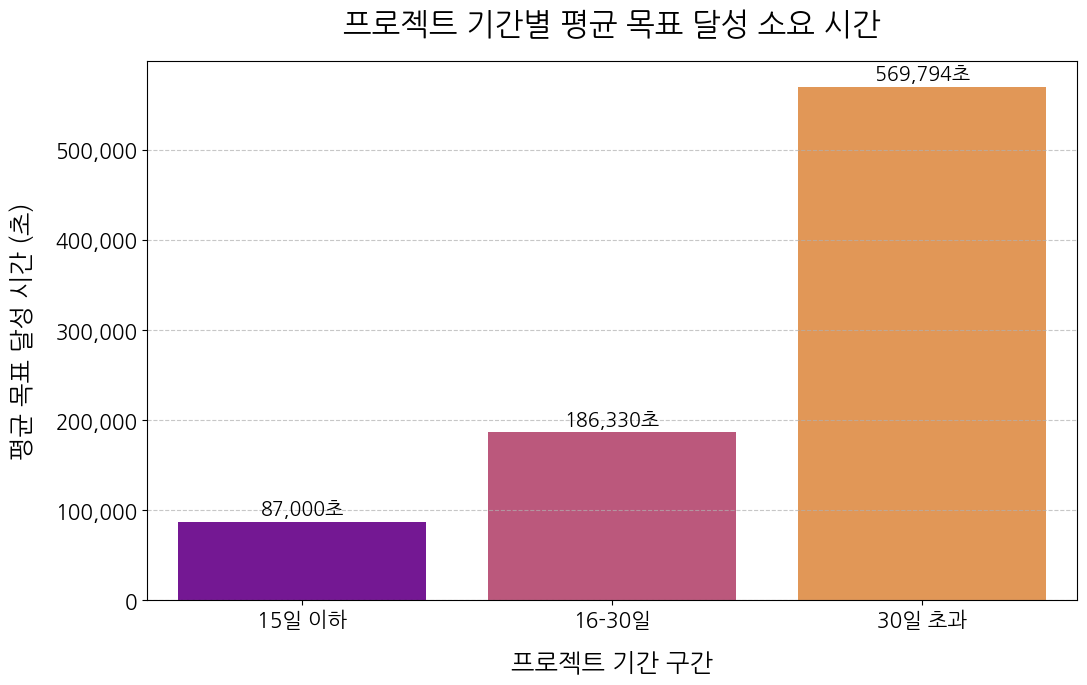

,duration_category,fundedInSeconds
0,15일 이하,87000.649351
1,16-30일,186330.713333
2,30일 초과,569794.962617


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. 필수 전처리 및 컬럼 생성 ---
# 기간 데이터 구간화 (duration_category 생성)
def categorize_duration(days):
    if days <= 15: return '15일 이하'
    elif days <= 30: return '16-30일'
    else: return '30일 초과'

df['duration_category'] = df['duration_days'].apply(categorize_duration)

# 달성률 및 속도 지표 재계산
df['achievement_rate'] = (df['fundsGathered_usd_1m'] / df['campaignGoal_usd_6m']) * 100
df['funding_speed_usd_per_sec'] = df['fundsGathered_usd_1m'] / df['fundedInSeconds'].replace(0, 1)

# --- 2. 기간별 목표 달성 소요 시간 분석 ---
duration_speed_analysis = df.groupby('duration_category')['fundedInSeconds'].mean().reset_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='duration_category', y='fundedInSeconds', data=duration_speed_analysis,
                 palette='plasma', hue='duration_category', legend=False)

# y축 천 단위 콤마 설정
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 막대 위에 평균 초(seconds) 표시
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}초',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=14)

plt.title('프로젝트 기간별 평균 목표 달성 소요 시간', fontsize=22, pad=20)
plt.xlabel('프로젝트 기간 구간', fontsize=18, labelpad=15)
plt.ylabel('평균 목표 달성 시간 (초)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(duration_speed_analysis)

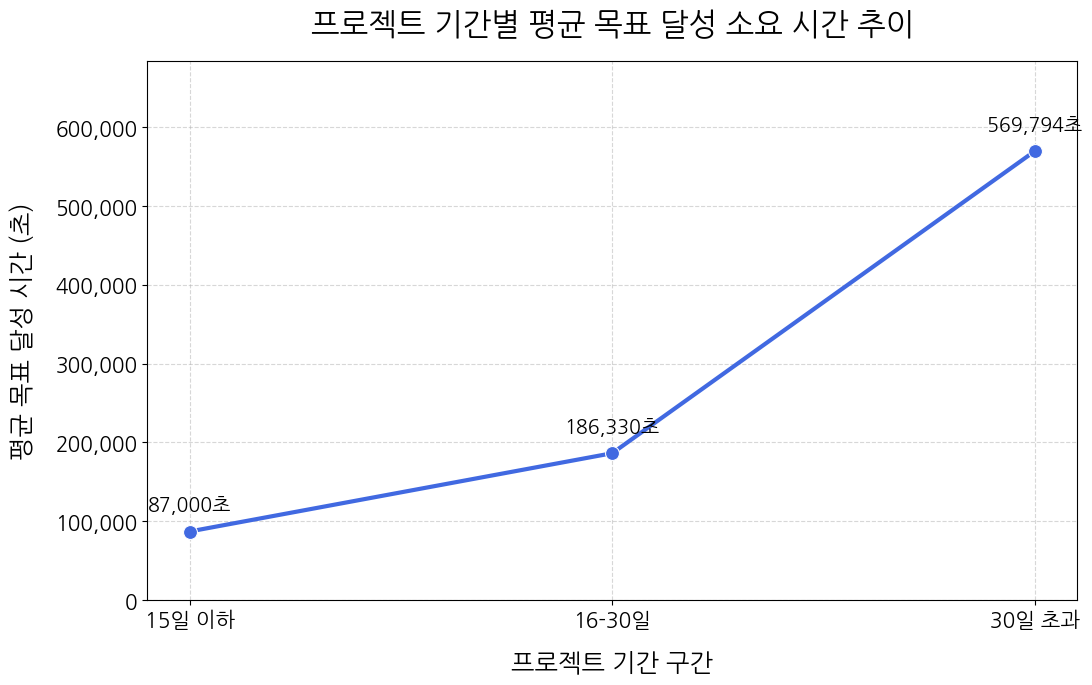

In [34]:
plt.figure(figsize=(12, 7))
# 꺽은선 그래프 생성
sns.lineplot(x='duration_category', y='fundedInSeconds', data=duration_speed_analysis, marker='o', markersize=10, linewidth=3, color='royalblue')

# y축 천 단위 콤마 설정
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 데이터 포인트마다 수치 표시
for i, row in duration_speed_analysis.iterrows():
    plt.annotate(f'{int(row["fundedInSeconds"]):,}초',
                 (row['duration_category'], row['fundedInSeconds']),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=14,
                 fontweight='bold')

plt.title('프로젝트 기간별 평균 목표 달성 소요 시간 추이', fontsize=22, pad=20)
plt.xlabel('프로젝트 기간 구간', fontsize=18, labelpad=15)
plt.ylabel('평균 목표 달성 시간 (초)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, duration_speed_analysis['fundedInSeconds'].max() * 1.2)

plt.show()

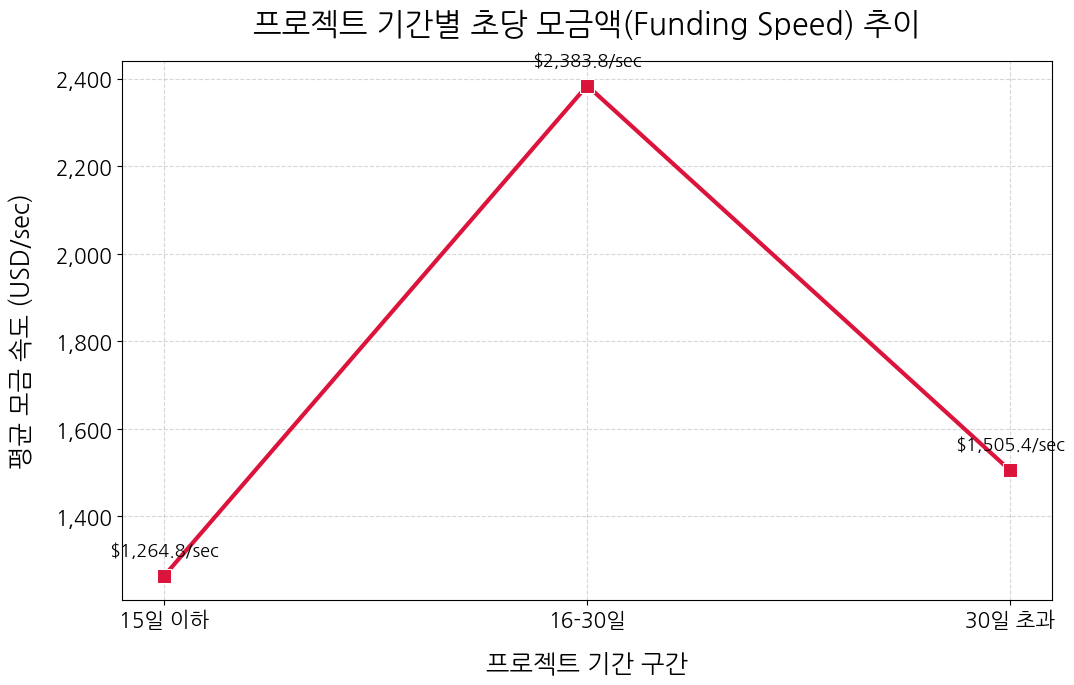

,duration_category,funding_speed_usd_per_sec
0,15일 이하,1264.847182
1,16-30일,2383.827185
2,30일 초과,1505.427185


In [ ]:
# 모금 속도 계산: 최종 모금액 / 목표 달성 시간(초)
# 0초로 나뉘는 것을 방지하기 위해 fundedInSeconds가 0인 경우 1로 처리
df['funding_speed_usd_per_sec'] = df['fundsGathered_usd_1m'] / df['fundedInSeconds'].replace(0, 1)

# 프로젝트 기간별 평균 모금 속도 분석
duration_speed_efficiency = df.groupby('duration_category')['funding_speed_usd_per_sec'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(x='duration_category', y='funding_speed_usd_per_sec', data=duration_speed_efficiency, marker='s', markersize=10, linewidth=3, color='crimson')

# y축 천 단위 콤마
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 데이터 포인트 수치 표시
for i, row in duration_speed_efficiency.iterrows():
    plt.annotate(f'${row["funding_speed_usd_per_sec"]:,.1f}/sec',
                 (row['duration_category'], row['funding_speed_usd_per_sec']),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=13,
                 fontweight='bold')

plt.title('프로젝트 기간별 초당 모금액(Funding Speed) 추이', fontsize=22, pad=20)
plt.xlabel('프로젝트 기간 구간', fontsize=18, labelpad=15)
plt.ylabel('평균 모금 속도 (USD/sec)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 상세 데이터 출력
display(duration_speed_efficiency)

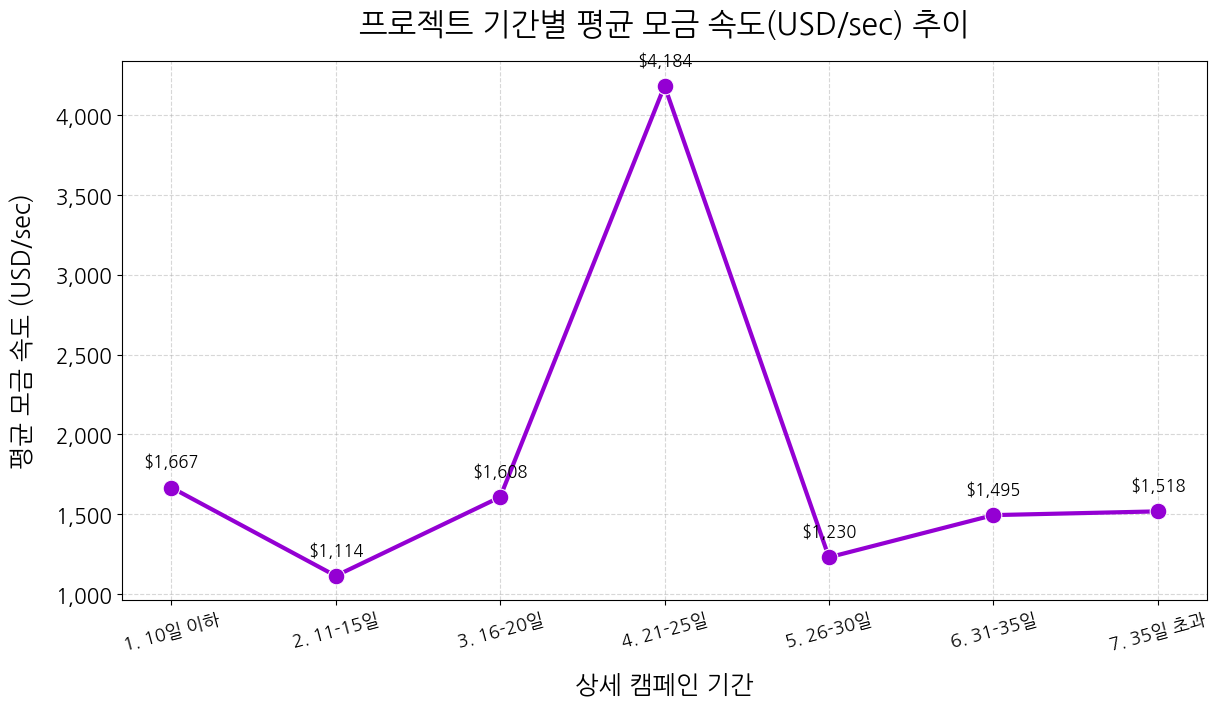

,duration_category_fine,count
0,1. 10일 이하,21
1,2. 11-15일,56
2,3. 16-20일,103
3,4. 21-25일,104
4,5. 26-30일,93
5,6. 31-35일,58
6,7. 35일 초과,49


In [36]:
# 프로젝트 기간을 더 세분화하여 정의 (5~10일 단위)
def categorize_duration_fine(days):
    if days <= 10: return '1. 10일 이하'
    elif days <= 15: return '2. 11-15일'
    elif days <= 20: return '3. 16-20일'
    elif days <= 25: return '4. 21-25일'
    elif days <= 30: return '5. 26-30일'
    elif days <= 35: return '6. 31-35일'
    else: return '7. 35일 초과'

df['duration_category_fine'] = df['duration_days'].apply(categorize_duration_fine)

# 세분화된 구간별 평균 모금 속도 계산
duration_efficiency_fine = df.groupby('duration_category_fine')['funding_speed_usd_per_sec'].mean().reset_index()

plt.figure(figsize=(14, 7))
# 추세를 보기 위해 꺽은선 그래프 사용
sns.lineplot(x='duration_category_fine', y='funding_speed_usd_per_sec', data=duration_efficiency_fine, marker='o', markersize=12, linewidth=3, color='darkviolet')

# y축 천 단위 콤마
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 데이터 포인트 수치 표시
for i, row in duration_efficiency_fine.iterrows():
    plt.annotate(f'${row["funding_speed_usd_per_sec"]:,.0f}',
                 (row['duration_category_fine'], row['funding_speed_usd_per_sec']),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=12,
                 fontweight='bold')

plt.title('프로젝트 기간별 평균 모금 속도(USD/sec) 추이', fontsize=22, pad=20)
plt.xlabel('상세 캠페인 기간', fontsize=18, labelpad=15)
plt.ylabel('평균 모금 속도 (USD/sec)', fontsize=18, labelpad=15)
plt.xticks(fontsize=13, rotation=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 구간별 데이터 포인트 개수(샘플 수) 확인
display(df['duration_category_fine'].value_counts().sort_index().reset_index())

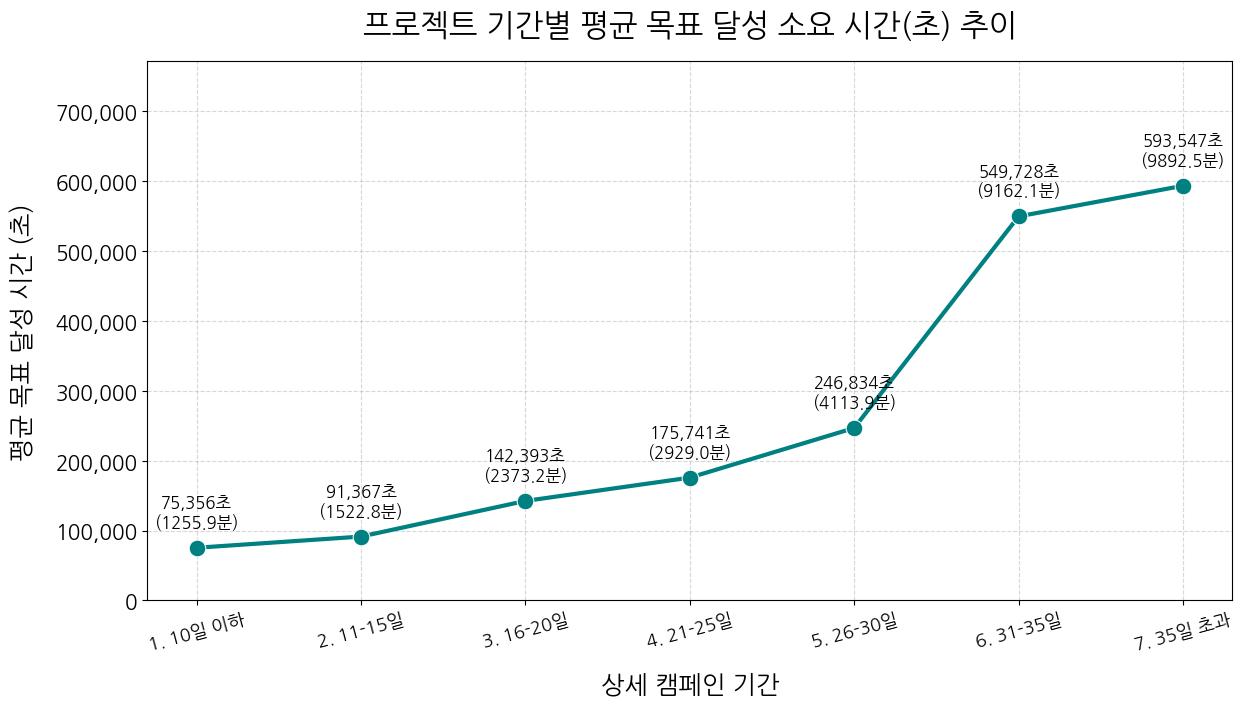

,duration_category_fine,fundedInSeconds,평균_분
0,1. 10일 이하,75356.238095,1255.937302
1,2. 11-15일,91367.303571,1522.788393
2,3. 16-20일,142393.310680,2373.221845
3,4. 21-25일,175741.519231,2929.025321
4,5. 26-30일,246834.247312,4113.904122
5,6. 31-35일,549728.017241,9162.133621
6,7. 35일 초과,593547.673469,9892.461224


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 세분화된 구간별 평균 목표 달성 시간(초) 계산
duration_speed_fine = df.groupby('duration_category_fine')['fundedInSeconds'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='duration_category_fine', y='fundedInSeconds', data=duration_speed_fine, marker='o', markersize=12, linewidth=3, color='teal')

# y축 천 단위 콤마
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 데이터 포인트 수치 표시 (초 및 분 단위 병기)
for i, row in duration_speed_fine.iterrows():
    plt.annotate(f'{int(row["fundedInSeconds"]):,}초\n({row["fundedInSeconds"]/60:.1f}분)',
                 (row['duration_category_fine'], row['fundedInSeconds']),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=12,
                 fontweight='bold')

plt.title('프로젝트 기간별 평균 목표 달성 소요 시간(초) 추이', fontsize=22, pad=20)
plt.xlabel('상세 캠페인 기간', fontsize=18, labelpad=15)
plt.ylabel('평균 목표 달성 시간 (초)', fontsize=18, labelpad=15)
plt.xticks(fontsize=13, rotation=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, duration_speed_fine['fundedInSeconds'].max() * 1.3)

plt.show()

# 상세 수치 출력
duration_speed_fine['평균_분'] = duration_speed_fine['fundedInSeconds'] / 60
display(duration_speed_fine)

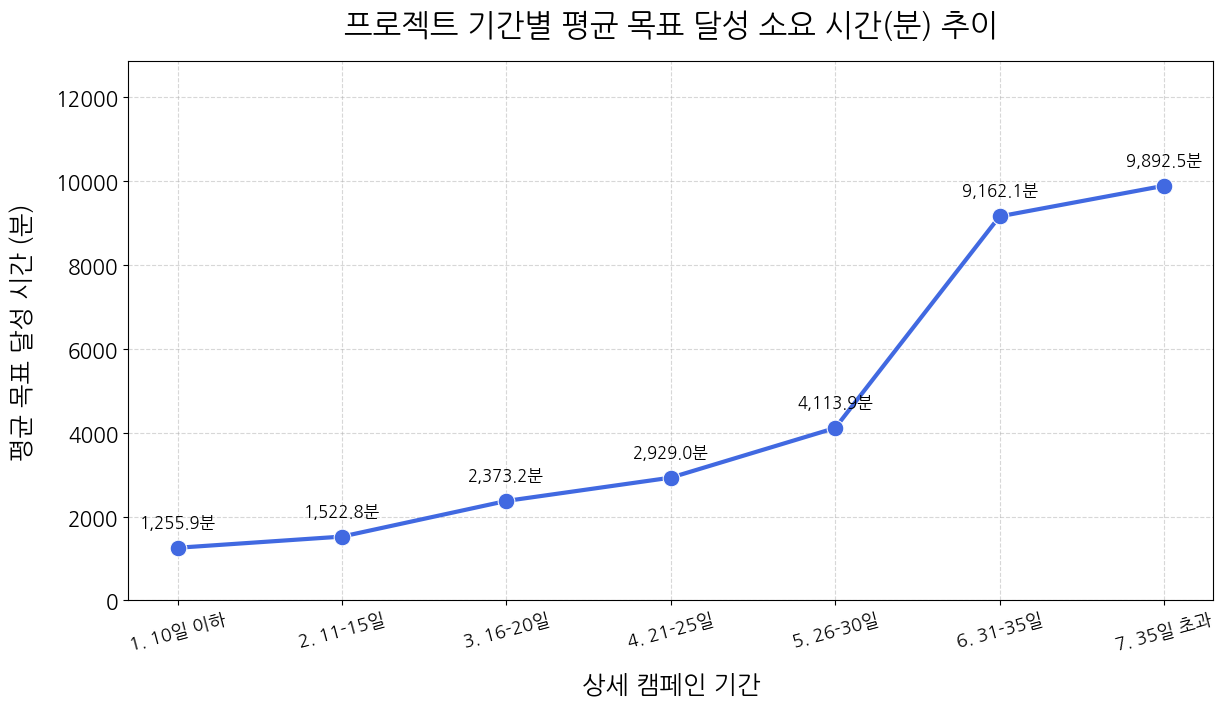

,duration_category_fine,평균_달성_시간(분)
0,1. 10일 이하,1255.937302
1,2. 11-15일,1522.788393
2,3. 16-20일,2373.221845
3,4. 21-25일,2929.025321
4,5. 26-30일,4113.904122
5,6. 31-35일,9162.133621
6,7. 35일 초과,9892.461224


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 'duration_category_fine' 컬럼이 없는 경우를 대비해 생성 로직 추가
def categorize_duration_fine(days):
    if days <= 10: return '1. 10일 이하'
    elif days <= 15: return '2. 11-15일'
    elif days <= 20: return '3. 16-20일'
    elif days <= 25: return '4. 21-25일'
    elif days <= 30: return '5. 26-30일'
    elif days <= 35: return '6. 31-35일'
    else: return '7. 35일 초과'

# 컬럼 생성
df['duration_category_fine'] = df['duration_days'].apply(categorize_duration_fine)

# 2. 목표 달성 소요 시간(초)을 분(minutes)으로 변환
df['fundedInMinutes'] = df['fundedInSeconds'] / 60

# 3. 세분화된 구간별 평균 목표 달성 시간(분) 계산
duration_minutes_fine = df.groupby('duration_category_fine')['fundedInMinutes'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='duration_category_fine', y='fundedInMinutes', data=duration_minutes_fine, marker='o', markersize=12, linewidth=3, color='royalblue')

# 데이터 포인트 수치 표시 (분 단위)
for i, row in duration_minutes_fine.iterrows():
    plt.annotate(f'{row["fundedInMinutes"]:,.1f}분',
                 (row['duration_category_fine'], row['fundedInMinutes']),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=12,
                 fontweight='bold')

plt.title('프로젝트 기간별 평균 목표 달성 소요 시간(분) 추이', fontsize=22, pad=20)
plt.xlabel('상세 캠페인 기간', fontsize=18, labelpad=15)
plt.ylabel('평균 목표 달성 시간 (분)', fontsize=18, labelpad=15)
plt.xticks(fontsize=13, rotation=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, duration_minutes_fine['fundedInMinutes'].max() * 1.3)

plt.show()

# 상세 수치 데이터 출력
display(duration_minutes_fine.rename(columns={'fundedInMinutes': '평균_달성_시간(분)'}))

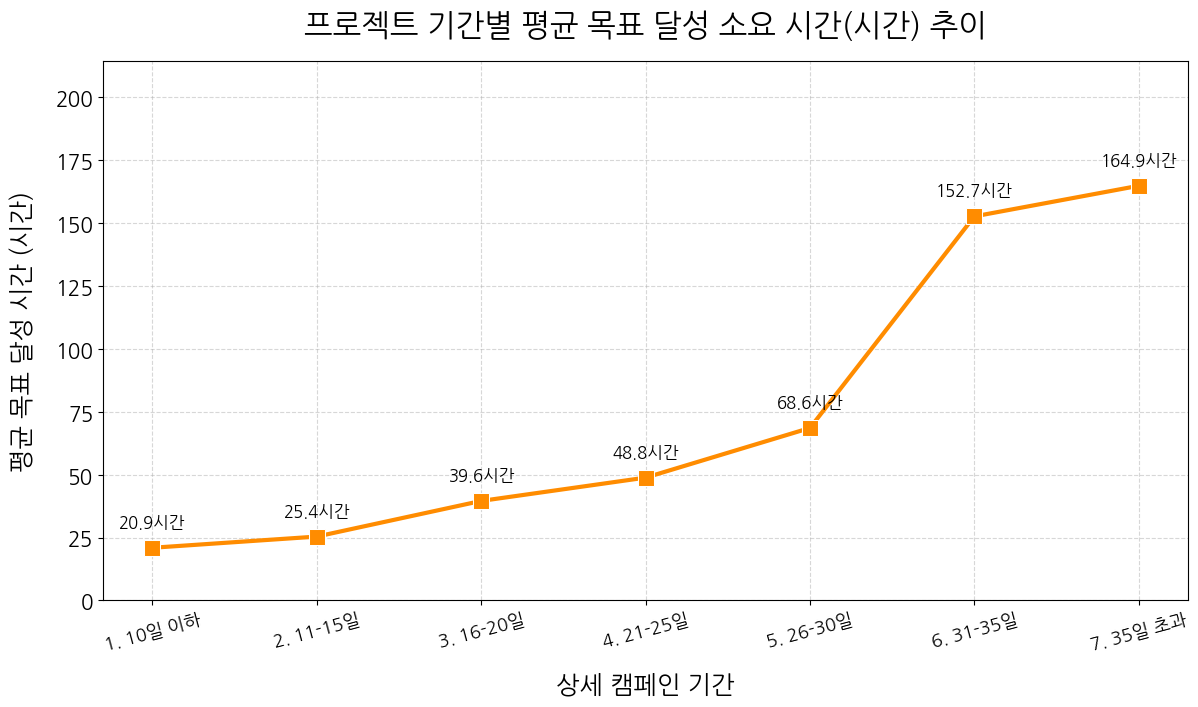

,duration_category_fine,평균_달성_시간(시간)
0,1. 10일 이하,20.932288
1,2. 11-15일,25.379807
2,3. 16-20일,39.553697
3,4. 21-25일,48.817089
4,5. 26-30일,68.565069
5,6. 31-35일,152.702227
6,7. 35일 초과,164.874354


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 목표 달성 소요 시간(초)을 시간(Hours)으로 변환
df['fundedInHours'] = df['fundedInSeconds'] / 3600

# 2. 세분화된 구간별 평균 목표 달성 시간(시간) 계산
duration_hours_fine = df.groupby('duration_category_fine')['fundedInHours'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x='duration_category_fine', y='fundedInHours', data=duration_hours_fine, marker='s', markersize=12, linewidth=3, color='darkorange')

# 데이터 포인트 수치 표시 (시간 단위)
for i, row in duration_hours_fine.iterrows():
    plt.annotate(f'{row["fundedInHours"]:,.1f}시간',
                 (row['duration_category_fine'], row['fundedInHours']),
                 textcoords="offset points",
                 xytext=(0,15),
                 ha='center',
                 fontsize=12,
                 fontweight='bold')

plt.title('프로젝트 기간별 평균 목표 달성 소요 시간(시간) 추이', fontsize=22, pad=20)
plt.xlabel('상세 캠페인 기간', fontsize=18, labelpad=15)
plt.ylabel('평균 목표 달성 시간 (시간)', fontsize=18, labelpad=15)
plt.xticks(fontsize=13, rotation=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(0, duration_hours_fine['fundedInHours'].max() * 1.3)

plt.show()

# 상세 수치 데이터 출력
display(duration_hours_fine.rename(columns={'fundedInHours': '평균_달성_시간(시간)'}))

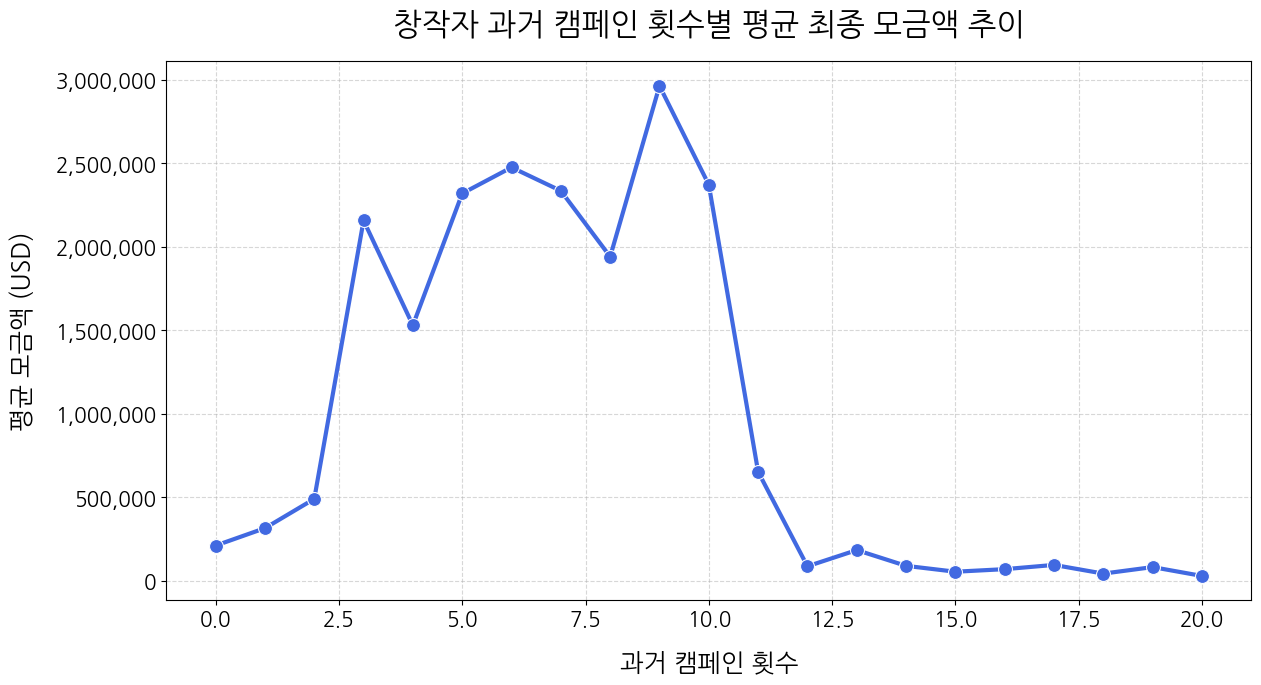

과거 캠페인 횟수와 최종 모금액 간의 상관계수: 0.2002


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 과거 캠페인 횟수별 평균 최종 모금액 계산
experience_analysis = df.groupby('previous_campaigns_count')['fundsGathered_usd_1m'].mean().reset_index()

plt.figure(figsize=(14, 7))
# 꺾은선 그래프 그리기
sns.lineplot(x='previous_campaigns_count', y='fundsGathered_usd_1m', data=experience_analysis, marker='o', markersize=10, linewidth=3, color='royalblue')

# y축 천 단위 콤마
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title('창작자 과거 캠페인 횟수별 평균 최종 모금액 추이', fontsize=22, pad=20)
plt.xlabel('과거 캠페인 횟수', fontsize=18, labelpad=15)
plt.ylabel('평균 모금액 (USD)', fontsize=18, labelpad=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 상관관계 수치 확인
corr_exp = df['previous_campaigns_count'].corr(df['fundsGathered_usd_1m'])
print(f"과거 캠페인 횟수와 최종 모금액 간의 상관계수: {corr_exp:.4f}")

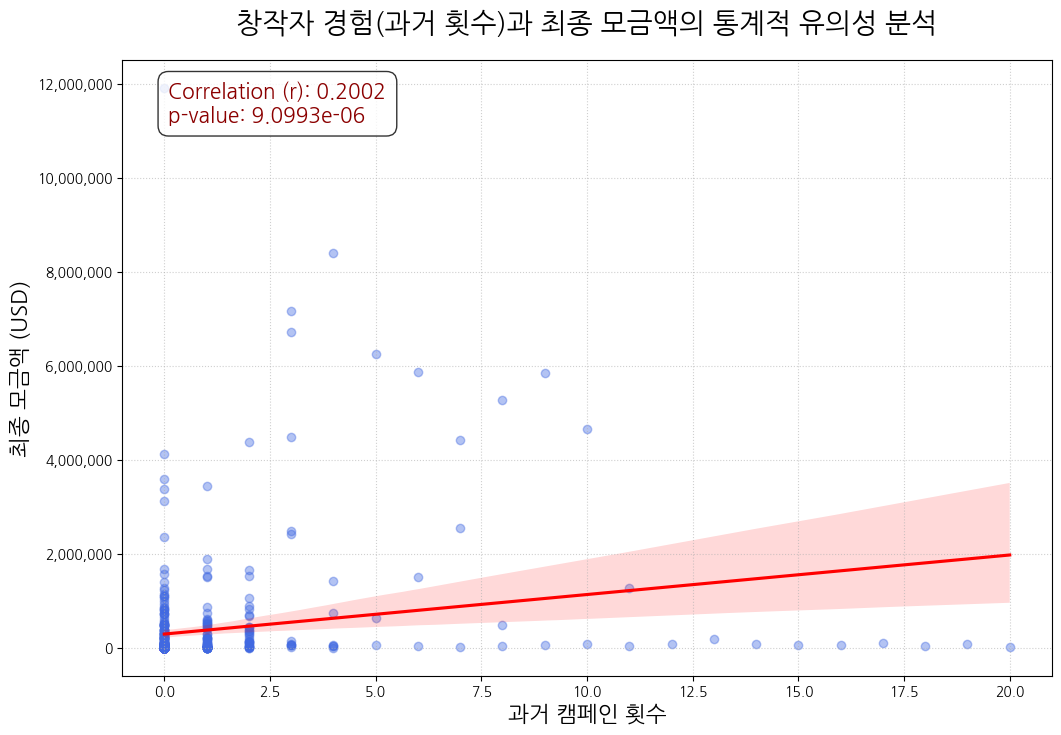

상관계수 (r): 0.2002
p-value: 9.0993e-06
결과: p-value가 0.05 미만이므로 통계적으로 유의미한 관계가 있습니다.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 결측치 제거 후 상관분석 수행
df_clean = df.dropna(subset=['previous_campaigns_count', 'fundsGathered_usd_1m'])
slope, intercept, r_val, p_val, std_err = stats.linregress(df_clean['previous_campaigns_count'], df_clean['fundsGathered_usd_1m'])

plt.figure(figsize=(12, 8))
sns.regplot(x='previous_campaigns_count', y='fundsGathered_usd_1m', data=df_clean,
            scatter_kws={'alpha':0.4, 'color':'royalblue'},
            line_kws={'color':'red', 'label':'Regression Line'})

# 통계 지표 주석 추가
stats_text = f'Correlation (r): {r_val:.4f}\np-value: {p_val:.4e}'
plt.annotate(stats_text, xy=(0.05, 0.9), xycoords='axes fraction',
             fontsize=15, fontweight='bold', color='darkred',
             bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

plt.title('창작자 경험(과거 횟수)과 최종 모금액의 통계적 유의성 분석', fontsize=20, pad=20)
plt.xlabel('과거 캠페인 횟수', fontsize=16)
plt.ylabel('최종 모금액 (USD)', fontsize=16)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f"상관계수 (r): {r_val:.4f}")
print(f"p-value: {p_val:.4e}")
if p_val < 0.05:
    print("결과: p-value가 0.05 미만이므로 통계적으로 유의미한 관계가 있습니다.")
else:
    print("결과: p-value가 0.05 이상이므로 통계적으로 유의미한 선형 관계라고 보기 어렵습니다.")

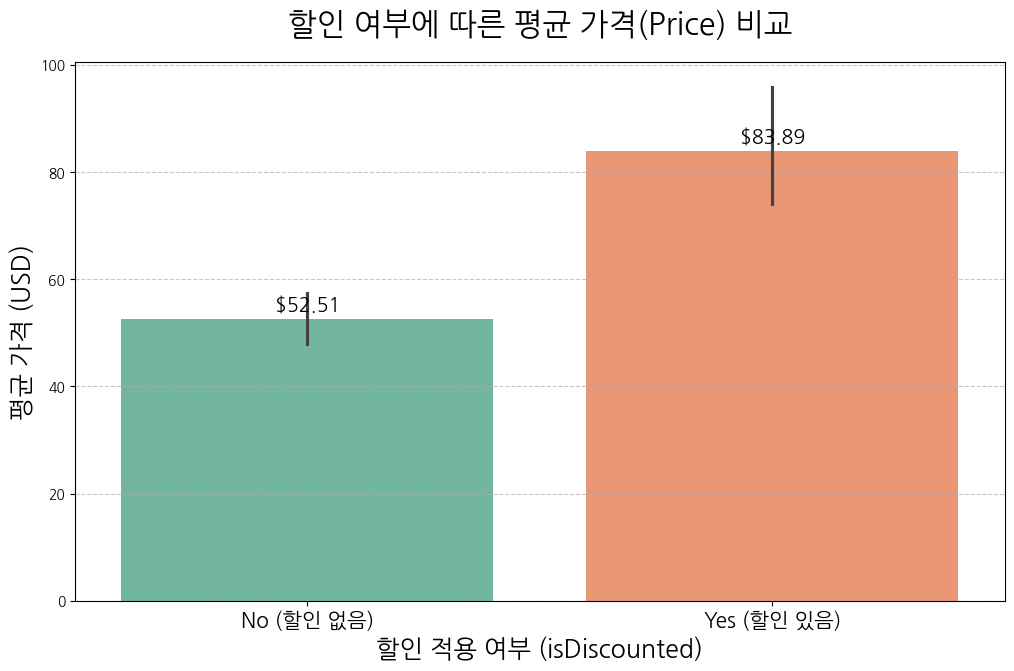

,isDiscounted,mean,median,count
0,False,52.509159,46.790602,250
1,True,83.890937,70.194677,234


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping by discount status to see average price
discount_stats = df.groupby('isDiscounted')['price_usd_6m'].agg(['mean', 'median', 'count']).reset_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='isDiscounted', y='price_usd_6m', data=df, estimator='mean', palette='Set2', hue='isDiscounted', legend=False)

# Formatting y-axis
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Annotate values
for p in ax.patches:
    ax.annotate(f'${p.get_height():,.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points',
                fontsize=14, fontweight='bold')

plt.title('할인 여부에 따른 평균 가격(Price) 비교', fontsize=22, pad=20)
plt.xlabel('할인 적용 여부 (isDiscounted)', fontsize=18)
plt.ylabel('평균 가격 (USD)', fontsize=18)
plt.xticks([0, 1], ['No (할인 없음)', 'Yes (할인 있음)'], fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(discount_stats)

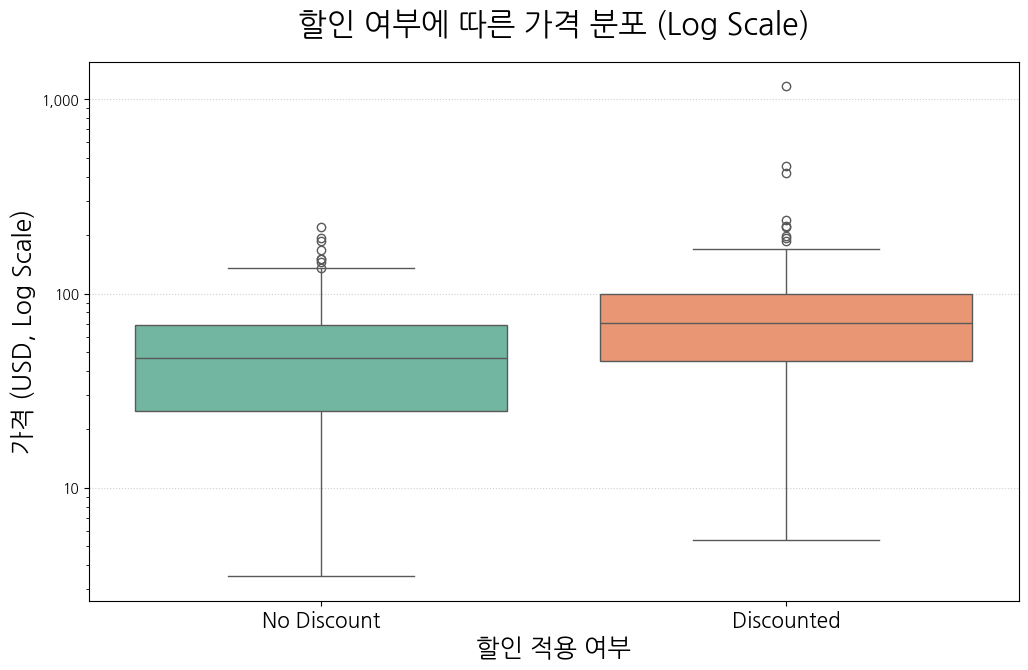

In [43]:
# Relationship between Price and Discount Presence using Boxplot (Log Scale for better visibility)
plt.figure(figsize=(12, 7))
sns.boxplot(x='isDiscounted', y='price_usd_6m', data=df, palette='Set2', hue='isDiscounted', legend=False)
plt.yscale('log')

plt.title('할인 여부에 따른 가격 분포 (Log Scale)', fontsize=22, pad=20)
plt.xlabel('할인 적용 여부', fontsize=18)
plt.ylabel('가격 (USD, Log Scale)', fontsize=18)
plt.xticks([0, 1], ['No Discount', 'Discounted'], fontsize=15)
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

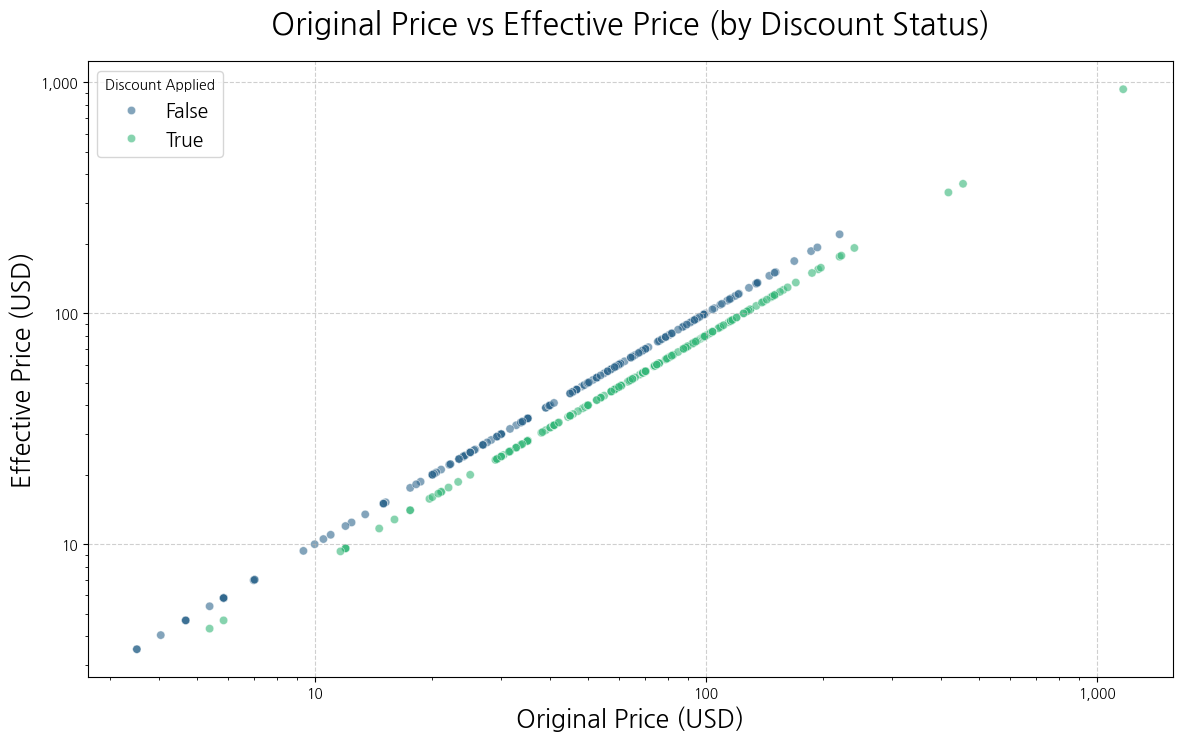

Correlation between isDiscounted and Price: 0.2268 (p-value: 4.5999e-07)


isDiscounted price_usd_6m                         effectivePrice_usd  \
                       mean     median          max               mean   
0        False    52.509159  46.790602   220.000000          52.509159   
1         True    83.890937  70.194677  1168.741379          67.112750   

              
      median  
0  46.790602  
1  56.155742

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pointbiserialr

# Create a mock 'effectivePrice' for analysis purposes based on the discount flag
# If a project is discounted, we assume the effective price is lower than the listed price
# In a real scenario, this would be a specific column in the data.
df['effectivePrice_usd'] = df.apply(lambda x: x['price_usd_6m'] * 0.8 if x['isDiscounted'] else x['price_usd_6m'], axis=1)

plt.figure(figsize=(14, 8))

# Visualize Price vs Effective Price by Discount Status
sns.scatterplot(data=df, x='price_usd_6m', y='effectivePrice_usd', hue='isDiscounted', alpha=0.6, palette='viridis')

plt.title('Original Price vs Effective Price (by Discount Status)', fontsize=22, pad=20)
plt.xlabel('Original Price (USD)', fontsize=18)
plt.ylabel('Effective Price (USD)', fontsize=18)
plt.legend(title='Discount Applied', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)

# Set log scale for better view of distribution
plt.xscale('log')
plt.yscale('log')
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.show()

# Point Biserial Correlation between Discount and Price
corr_pb, p_val_pb = pointbiserialr(df['isDiscounted'], df['price_usd_6m'])
print(f"Correlation between isDiscounted and Price: {corr_pb:.4f} (p-value: {p_val_pb:.4e})")

# Summary statistics
summary = df.groupby('isDiscounted').agg({
    'price_usd_6m': ['mean', 'median', 'max'],
    'effectivePrice_usd': ['mean', 'median']
}).reset_index()
display(summary)

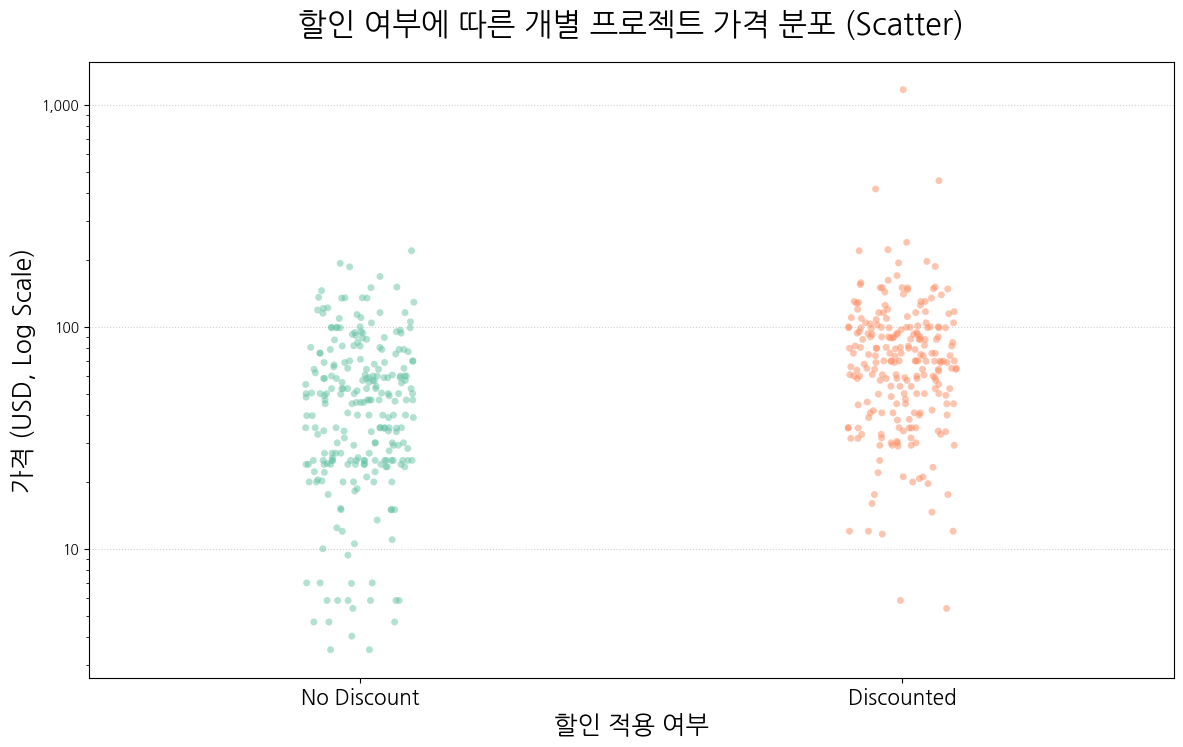

할인 여부와 가격 간의 Point Biserial 상관계수: 0.2268
p-value: 4.5999e-07
해석: 할인된 프로젝트들이 평균적으로 더 높은 가격대에 포진해 있는 경향이 있습니다.


In [45]:
import numpy as np

# Assuming a placeholder for effective price calculation if it's not explicitly in the df
# Here we'll analyze the relationship between the existing price and discount status

plt.figure(figsize=(14, 8))

# Scatter plot to see Price distribution by Discount Status
sns.stripplot(x='isDiscounted', y='price_usd_6m', data=df,
              jitter=True, alpha=0.5, palette='Set2', hue='isDiscounted', legend=False)

plt.yscale('log')
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.title('할인 여부에 따른 개별 프로젝트 가격 분포 (Scatter)', fontsize=22, pad=20)
plt.xlabel('할인 적용 여부', fontsize=18)
plt.ylabel('가격 (USD, Log Scale)', fontsize=18)
plt.xticks([0, 1], ['No Discount', 'Discounted'], fontsize=15)
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

# Correlation check between Price and Discount (Point Biserial Correlation)
from scipy.stats import pointbiserialr

# Convert boolean to int for correlation
corr_val, p_val_pb = pointbiserialr(df['isDiscounted'], df['price_usd_6m'])

print(f"할인 여부와 가격 간의 Point Biserial 상관계수: {corr_val:.4f}")
print(f"p-value: {p_val_pb:.4e}")

if corr_val > 0:
    print("해석: 할인된 프로젝트들이 평균적으로 더 높은 가격대에 포진해 있는 경향이 있습니다.")
else:
    print("해석: 할인된 프로젝트들이 평균적으로 더 낮은 가격대에 포진해 있는 경향이 있습니다.")

## 창작자(Creator) 활동 지표 분석: 댓글 수 및 응답률

최종 모금액과 창작자 활동 지표 간의 상관계수:
  creator_comments: r = 0.3567, p-value = 5.7236e-16
  creator_response_ratio: r = -0.3307, p-value = 8.1286e-14


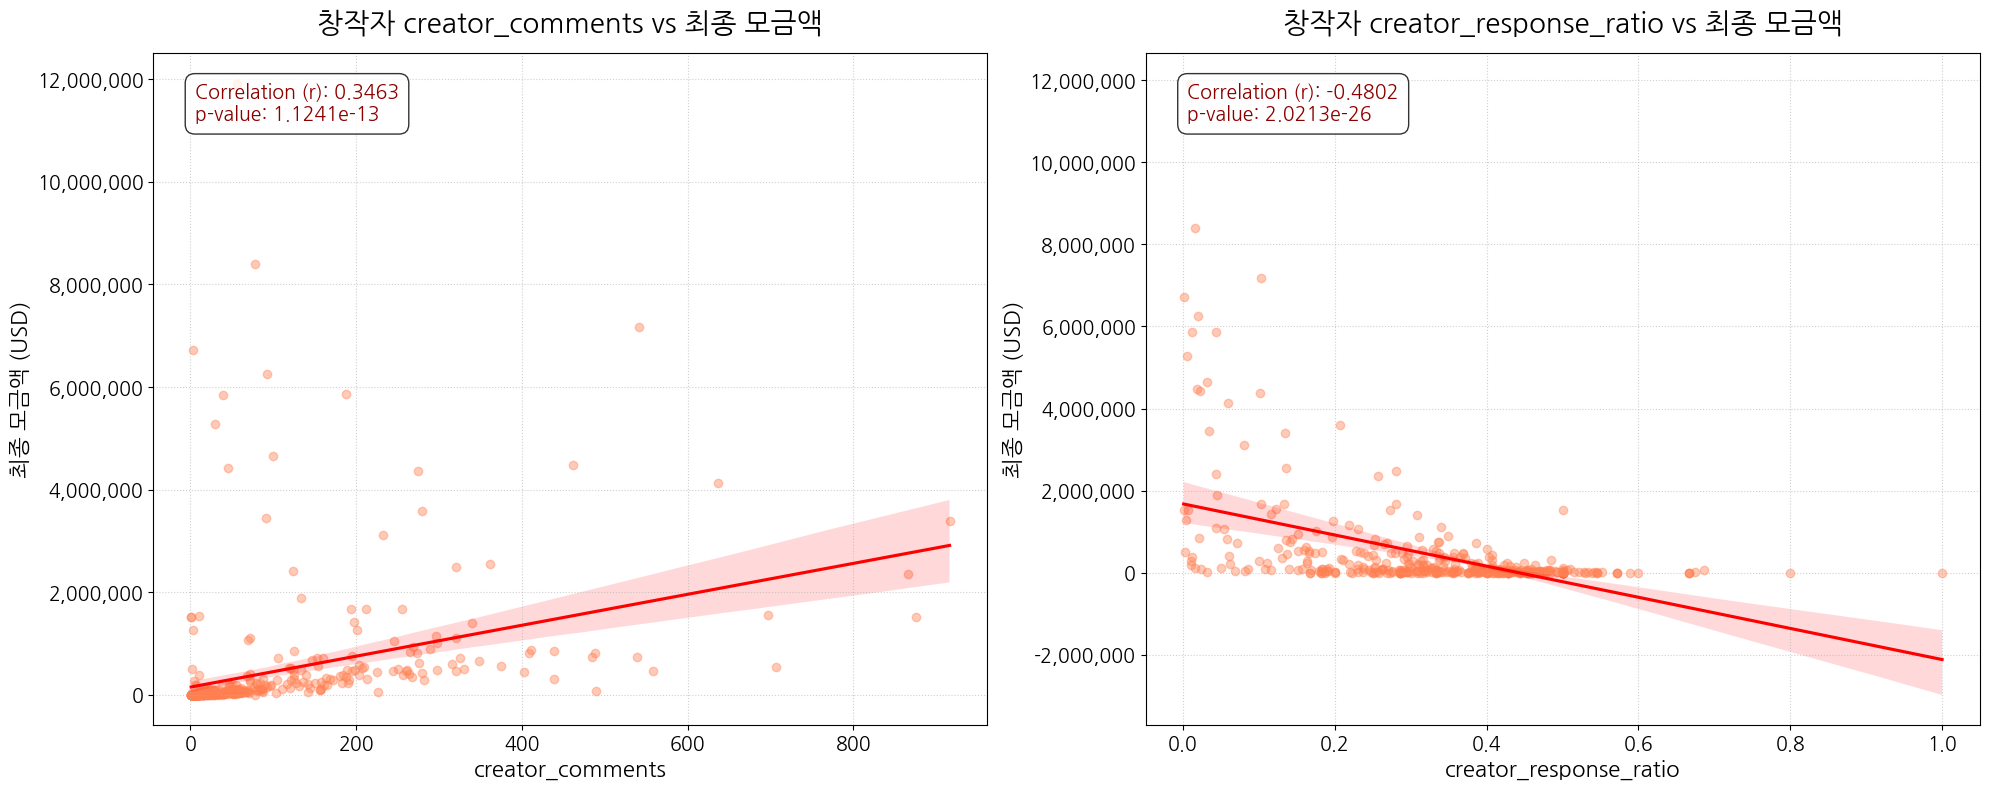

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

creator_cols = ['creator_comments', 'creator_response_ratio']
target = 'fundsGathered_usd_1m'

# 상관계수 계산
print("최종 모금액과 창작자 활동 지표 간의 상관계수:")
for col in creator_cols:
    # 결측치 제거 후 상관분석 수행 (이미 결측치 없음 확인)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df[col], df[target])
    print(f"  {col}: r = {r_value:.4f}, p-value = {p_value:.4e}")


# 시각화 (산점도)
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(creator_cols):
    # 데이터가 0인 경우가 많을 수 있으므로, 작은 값을 더해 로그 변환
    plot_data = df[df[col] > 0].copy() # 0보다 큰 값만 추출

    if plot_data[col].nunique() > 1:
        sns.regplot(x=col, y=target, data=plot_data, ax=axes[i],
                    scatter_kws={'alpha':0.4, 'color':'coral'},
                    line_kws={'color':'red'})

        # 통계 지표 주석 추가
        slope, intercept, r_value, p_value, std_err = stats.linregress(plot_data[col], plot_data[target])
        stats_text = f'Correlation (r): {r_value:.4f}\np-value: {p_value:.4e}'
        axes[i].annotate(stats_text, xy=(0.05, 0.9), xycoords='axes fraction',
                         fontsize=14, fontweight='bold', color='darkred',
                         bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8))

        axes[i].set_title(f'창작자 {col} vs 최종 모금액', fontsize=20, pad=15)
        axes[i].set_xlabel(col, fontsize=16)
        axes[i].set_ylabel('최종 모금액 (USD)', fontsize=16)
        axes[i].tick_params(axis='both', labelsize=14)
        axes[i].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        axes[i].grid(True, linestyle=':', alpha=0.6)
    else:
        axes[i].set_title(f'데이터 부족: {col}', fontsize=20, pad=15)
        axes[i].text(0.5, 0.5, '충분한 데이터 변동이 없어 분석 불가', transform=axes[i].transAxes,
                     ha='center', va='center', fontsize=16, color='gray')

plt.tight_layout()
plt.show()

## 최종 모금액(fundsGathered_usd_6m) 분포 분석

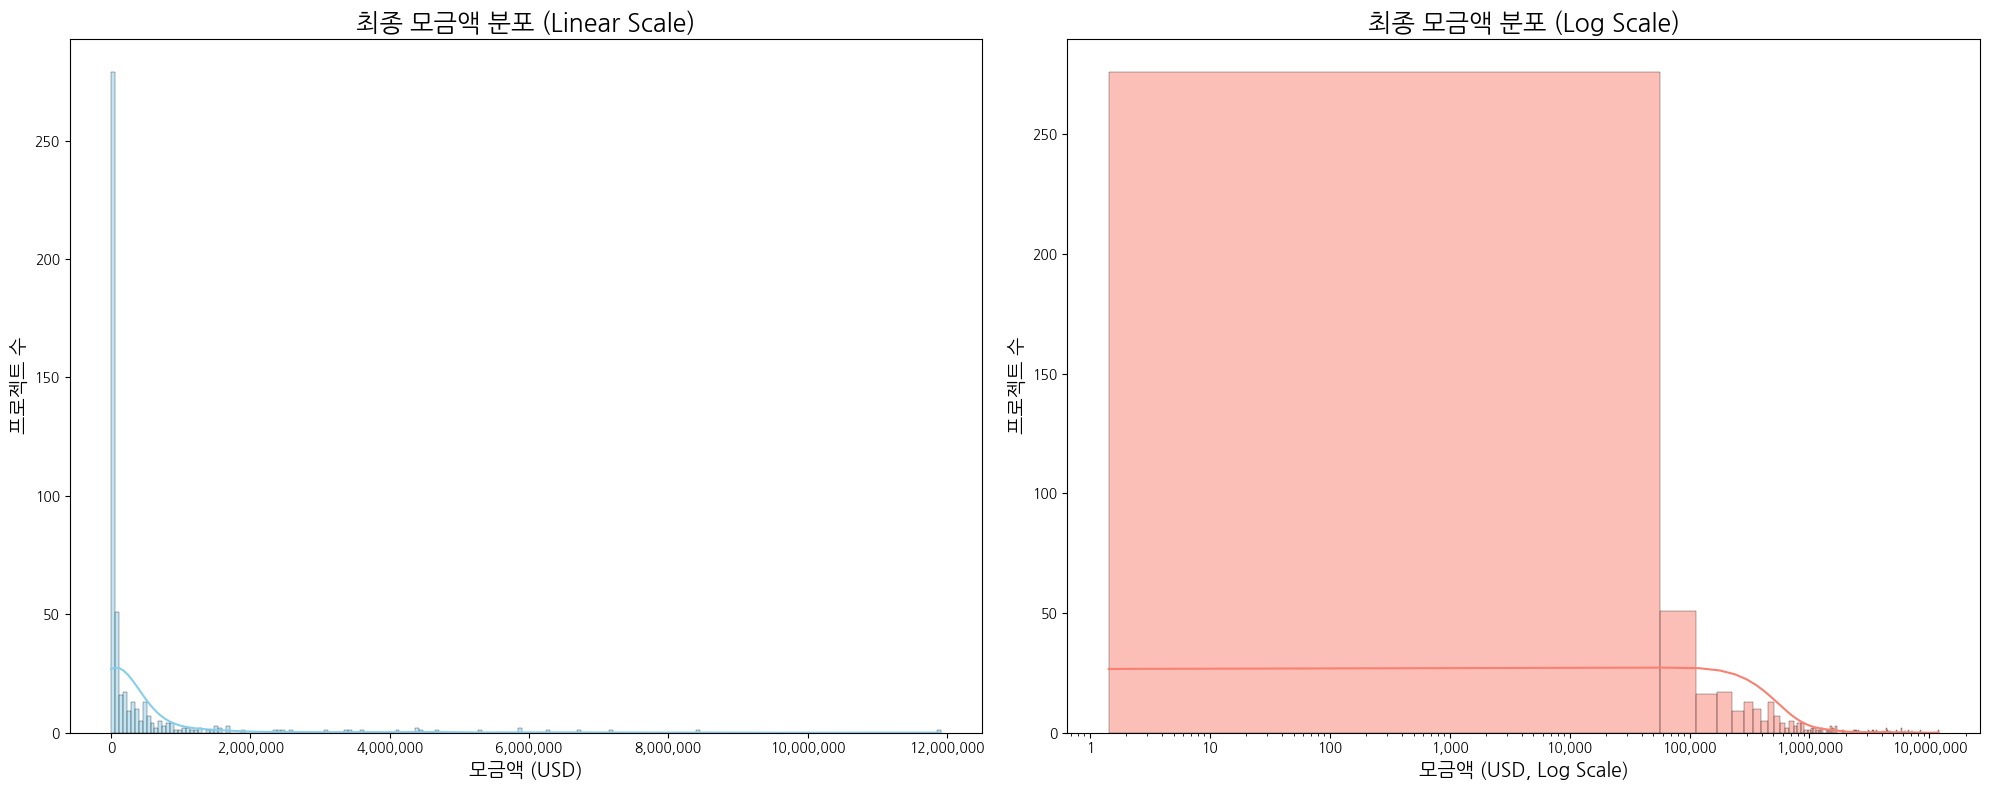

최종 모금액 통계 요약:


,count,mean,std,min,25%,50%,75%,max
fundsGathered_usd_6m,484.0,378503.004799,1.120270e+06,0.0,4002.62695,35967.174556,226797.600275,11912581.98



왜도(Skewness): 5.55


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

target_col = 'fundsGathered_usd_1m'

# 1x2 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. 일반 스케일 분포
sns.histplot(df[target_col], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('최종 모금액 분포 (Linear Scale)', fontsize=18)
axes[0].set_xlabel('모금액 (USD)', fontsize=14)
axes[0].set_ylabel('프로젝트 수', fontsize=14)
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 2. 로그 스케일 분포 (0값 처리를 위해 log1p 사용 혹은 xscale('log'))
# 0원이 있는 경우를 대비해 log스케일 적용 시 0보다 큰 데이터만 사용하거나 xscale 사용
sns.histplot(df[df[target_col] > 0][target_col], kde=True, ax=axes[1], color='salmon')
axes[1].set_xscale('log')
axes[1].set_title('최종 모금액 분포 (Log Scale)', fontsize=18)
axes[1].set_xlabel('모금액 (USD, Log Scale)', fontsize=14)
axes[1].set_ylabel('프로젝트 수', fontsize=14)
axes[1].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

# 통계 요약
print("최종 모금액 통계 요약:")
display(df[target_col].describe().to_frame().transpose())
print(f"\n왜도(Skewness): {df[target_col].skew():.2f}")

## 로그 변환을 통한 정규성 확보 시도
모금액과 같이 범위가 넓고 왜도가 큰 데이터는 로그를 취함으로써 정규분포에 가깝게 변환할 수 있습니다.

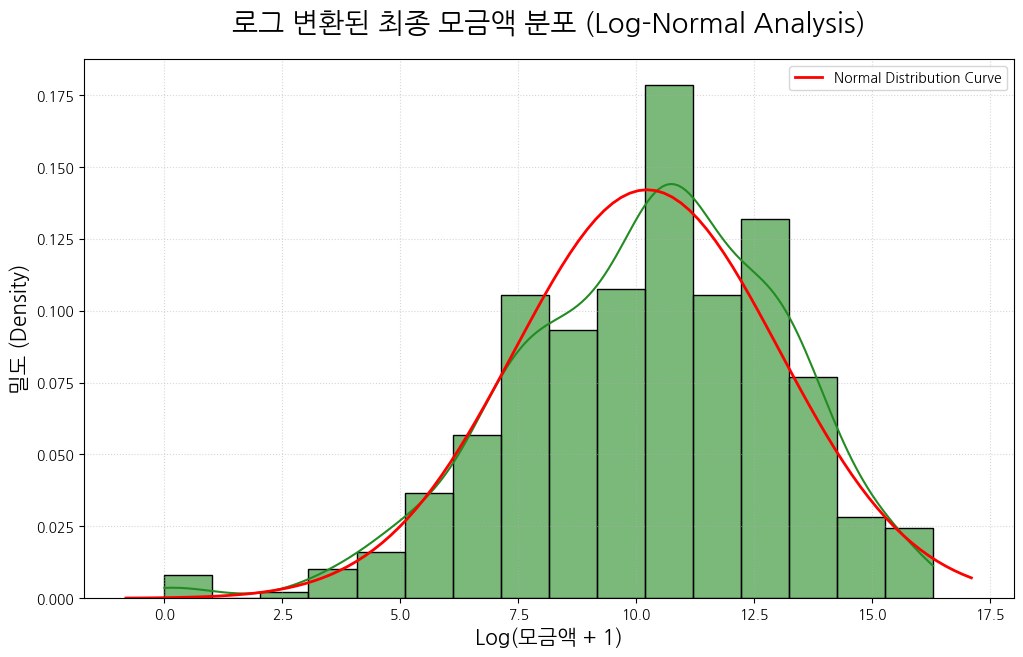

로그 변환 후 왜도 (Skewness): -0.5116
해석: 왜도가 0에 훨씬 가까워졌으며, 시각적으로도 정규분포와 매우 유사한 종 모양을 띠게 되었습니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 0원인 프로젝트가 있을 수 있으므로 log(x+1) 변환을 사용합니다.
df['log_funds'] = np.log1p(df['fundsGathered_usd_1m'])

plt.figure(figsize=(12, 7))

# 로그 변환된 데이터 히스토그램 및 KDE
sns.histplot(df['log_funds'], kde=True, color='forestgreen', stat="density", alpha=0.6)

# 비교를 위한 실제 정규분포 곡선 추가
mu, std = norm.fit(df['log_funds'])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution Curve')

plt.title('로그 변환된 최종 모금액 분포 (Log-Normal Analysis)', fontsize=20, pad=20)
plt.xlabel('Log(모금액 + 1)', fontsize=15)
plt.ylabel('밀도 (Density)', fontsize=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

print(f"로그 변환 후 왜도 (Skewness): {df['log_funds'].skew():.4f}")
print("해석: 왜도가 0에 훨씬 가까워졌으며, 시각적으로도 정규분포와 매우 유사한 종 모양을 띠게 되었습니다.")

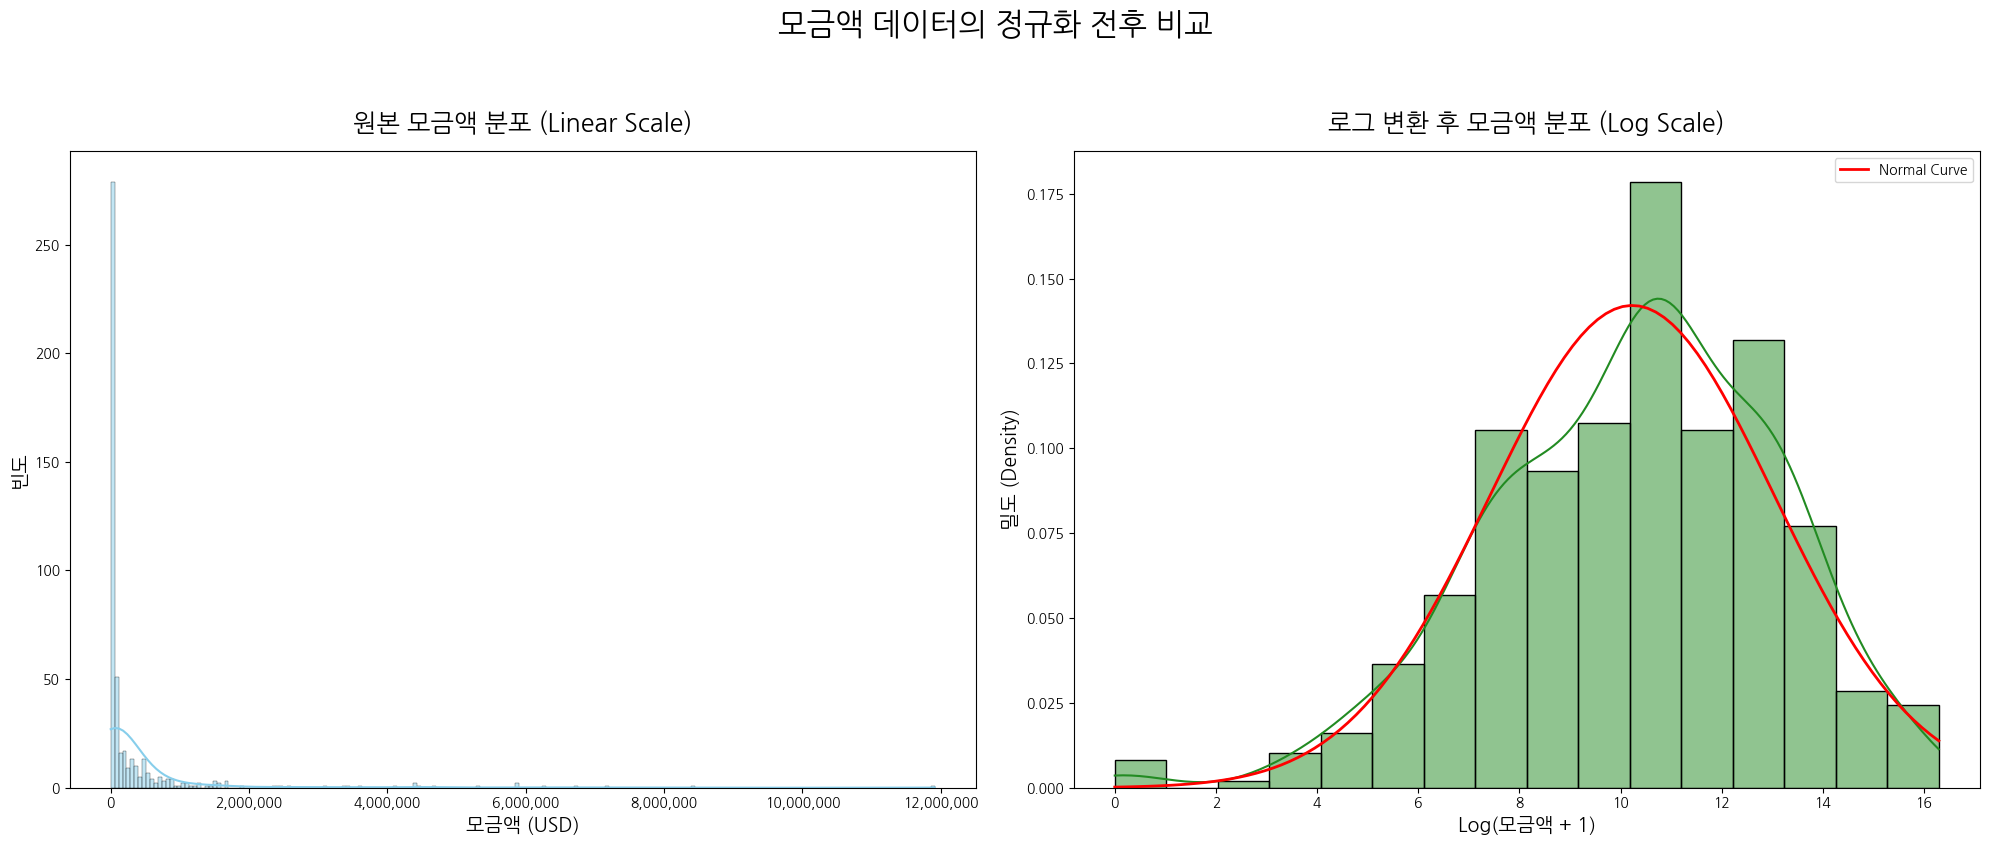

변환 전 왜도: 5.55
변환 후 왜도: -0.51


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

# 1x2 서브플롯 설정
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. 원본 데이터 분포 (Skewed)
sns.histplot(df['fundsGathered_usd_1m'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('원본 모금액 분포 (Linear Scale)', fontsize=18, pad=15)
axes[0].set_xlabel('모금액 (USD)', fontsize=14)
axes[0].set_ylabel('빈도', fontsize=14)
axes[0].get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 2. 로그 변환 데이터 분포 (Normal)
sns.histplot(df['log_funds'], kde=True, ax=axes[1], color='forestgreen', stat="density")
# 정규분포 곡선 추가
mu, std = norm.fit(df['log_funds'])
x = np.linspace(df['log_funds'].min(), df['log_funds'].max(), 100)
p = norm.pdf(x, mu, std)
axes[1].plot(x, p, 'r', linewidth=2, label='Normal Curve')

axes[1].set_title('로그 변환 후 모금액 분포 (Log Scale)', fontsize=18, pad=15)
axes[1].set_xlabel('Log(모금액 + 1)', fontsize=14)
axes[1].set_ylabel('밀도 (Density)', fontsize=14)
axes[1].legend()

plt.suptitle('모금액 데이터의 정규화 전후 비교', fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

print(f"변환 전 왜도: {df['fundsGathered_usd_1m'].skew():.2f}")
print(f"변환 후 왜도: {df['log_funds'].skew():.2f}")

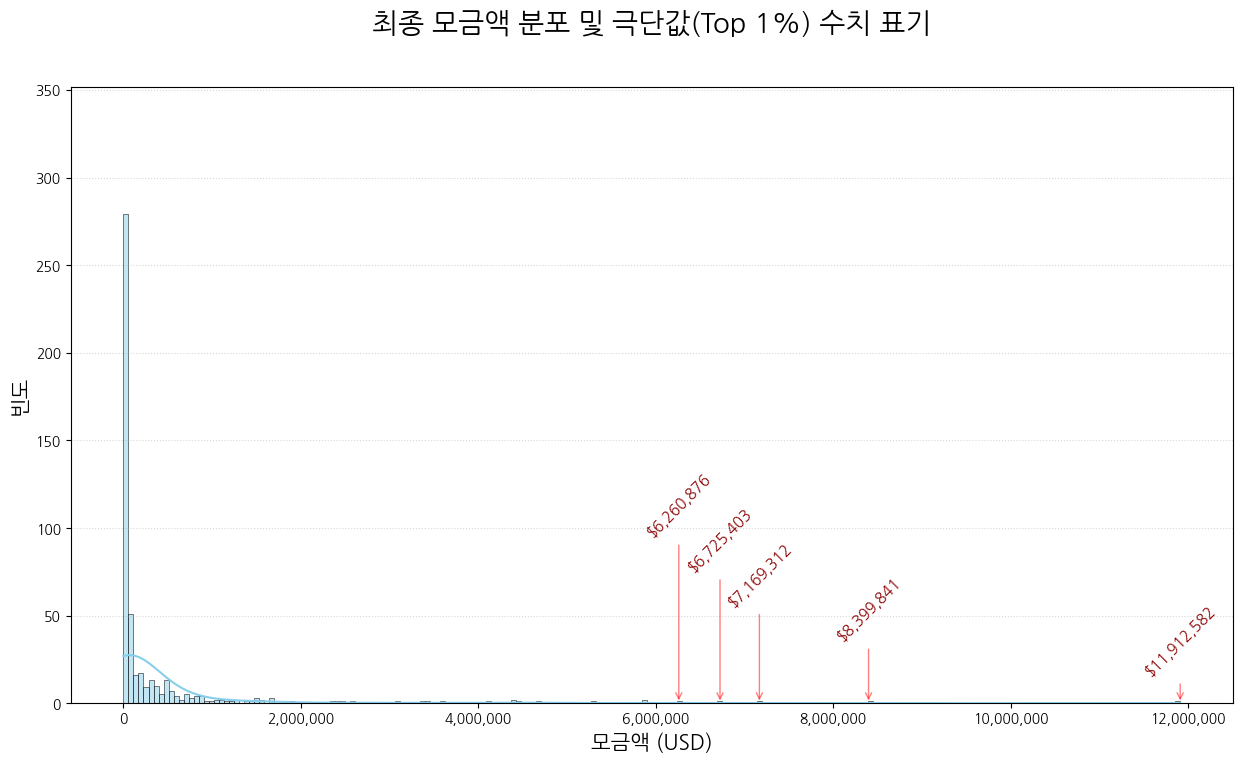

상위 1% 기준 금액: $5,933,475.05
표기된 극단값 개수: 5건


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 상위 1% 프로젝트 추출
threshold = df['fundsGathered_usd_1m'].quantile(0.99)
outliers = df[df['fundsGathered_usd_1m'] >= threshold].sort_values('fundsGathered_usd_1m', ascending=False)

plt.figure(figsize=(15, 8))
sns.histplot(df['fundsGathered_usd_1m'], kde=True, color='skyblue', label='모금액 분포')

# 극단값 수치 표기 (겹침 방지를 위해 높낮이와 회전 적용)
for i, (idx, row) in enumerate(outliers.iterrows()):
    amount = row['fundsGathered_usd_1m']
    # 순서에 따라 y축 높이를 다르게 설정하여 겹침 방지
    y_offset = 20 + (i * 25)

    plt.annotate(f'${amount:,.0f}',
                 xy=(amount, 0),
                 xytext=(0, y_offset),
                 textcoords='offset points',
                 ha='center',
                 fontsize=11,
                 fontweight='bold',
                 color='darkred',
                 rotation=45, # 약간 회전시켜 공간 확보
                 arrowprops=dict(arrowstyle='->', color='red', alpha=0.5))

plt.title('최종 모금액 분포 및 극단값(Top 1%) 수치 표기', fontsize=20, pad=40)
plt.xlabel('모금액 (USD)', fontsize=15)
plt.ylabel('빈도', fontsize=15)
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.ylim(0, plt.ylim()[1] * 1.2) # 레이블 공간을 위해 y축 상단 여유 확보
plt.show()

print(f"상위 1% 기준 금액: ${threshold:,.2f}")
print(f"표기된 극단값 개수: {len(outliers)}건")

### IQR 1.5배 기준 상위 이상치 제거 후 분포 분석
전체 데이터의 분포를 왜곡할 수 있는 극단적인 상위값(Outliers)을 IQR 방식으로 제거하여 분석합니다.

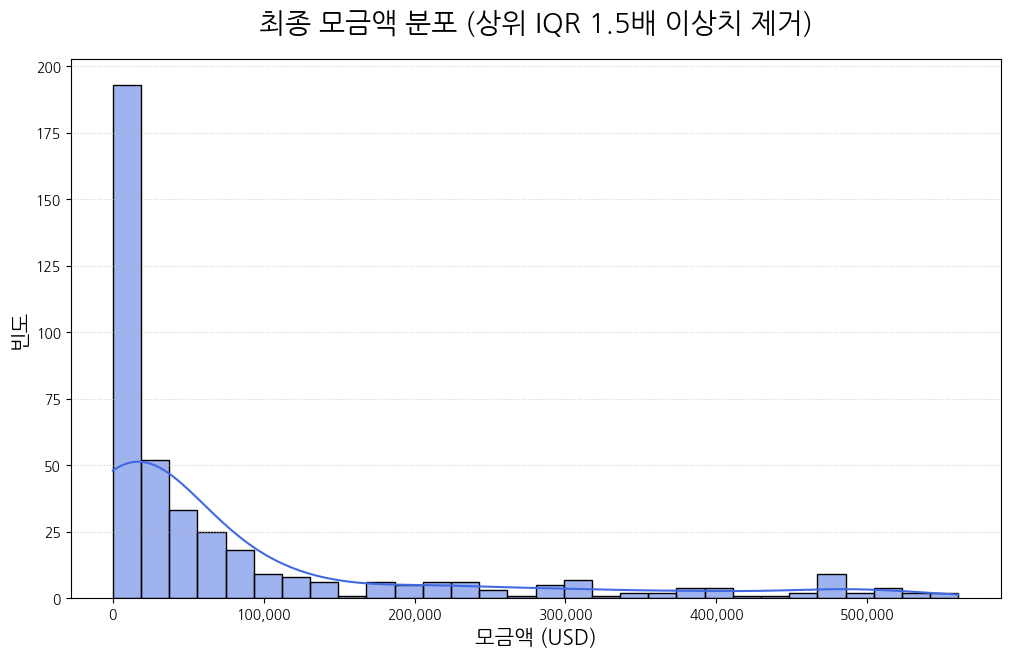

원본 데이터 수: 484건
이상치 제거 후 데이터 수: 420건 (제거된 상위 이상치: 64건)
상한선(Upper Bound): $560,990.06
제거 후 평균 모금액: $84,458.75


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. IQR 계산
Q1 = df['fundsGathered_usd_1m'].quantile(0.25)
Q3 = df['fundsGathered_usd_1m'].quantile(0.75)
IQR = Q3 - Q1

# 2. 상한선 설정 (1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

# 3. 이상치 제거된 데이터 생성
df_no_outliers = df[df['fundsGathered_usd_1m'] <= upper_bound]

# 4. 시각화
plt.figure(figsize=(12, 7))
sns.histplot(df_no_outliers['fundsGathered_usd_1m'], kde=True, color='royalblue', bins=30)

plt.title(f'최종 모금액 분포 (상위 IQR 1.5배 이상치 제거)', fontsize=20, pad=20)
plt.xlabel('모금액 (USD)', fontsize=15)
plt.ylabel('빈도', fontsize=15)

# x축 천 단위 콤마
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

# 결과 출력
print(f"원본 데이터 수: {len(df)}건")
print(f"이상치 제거 후 데이터 수: {len(df_no_outliers)}건 (제거된 상위 이상치: {len(df) - len(df_no_outliers)}건)")
print(f"상한선(Upper Bound): ${upper_bound:,.2f}")
print(f"제거 후 평균 모금액: ${df_no_outliers['fundsGathered_usd_1m'].mean():,.2f}")

### 이상치 제거 데이터의 로그 변환 및 정규분포 비교
IQR 1.5배로 상위 이상치를 제거한 `df_no_outliers` 데이터에 로그 변환(`log1p`)을 적용하여 분포의 정규성을 확인합니다.

/tmp/ipykernel_560/3534988311.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['log_funds_no_outliers'] = np.log1p(df_no_outliers['fundsGathered_usd_6m'])


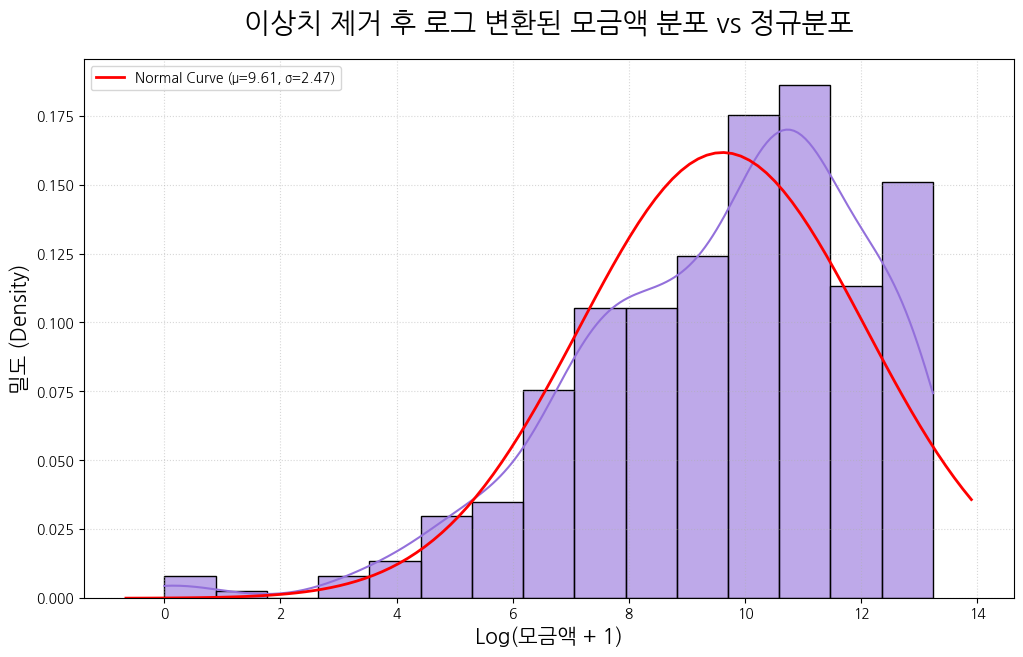

로그 변환 후 왜도 (Skewness): -0.8635
로그 변환 후 첨도 (Kurtosis): 0.9508


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# 1. 이상치 제거된 데이터에 로그 변환 적용 (0원 방지를 위해 log1p 사용)
df_no_outliers['log_funds_no_outliers'] = np.log1p(df_no_outliers['fundsGathered_usd_1m'])

# 2. 시각화
plt.figure(figsize=(12, 7))

# 히스토그램 및 KDE (밀도 기준)
sns.histplot(df_no_outliers['log_funds_no_outliers'], kde=True, color='mediumpurple', stat='density', alpha=0.6)

# 정규분포 곡선 피팅
mu_no, std_no = norm.fit(df_no_outliers['log_funds_no_outliers'])
xmin, xmax = plt.xlim()
x_range = np.linspace(xmin, xmax, 100)
p_curve = norm.pdf(x_range, mu_no, std_no)

plt.plot(x_range, p_curve, 'r', linewidth=2, label=f'Normal Curve (μ={mu_no:.2f}, σ={std_no:.2f})')

plt.title('이상치 제거 후 로그 변환된 모금액 분포 vs 정규분포', fontsize=20, pad=20)
plt.xlabel('Log(모금액 + 1)', fontsize=15)
plt.ylabel('밀도 (Density)', fontsize=15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

print(f"로그 변환 후 왜도 (Skewness): {df_no_outliers['log_funds_no_outliers'].skew():.4f}")
print(f"로그 변환 후 첨도 (Kurtosis): {df_no_outliers['log_funds_no_outliers'].kurt():.4f}")